## Section 1 — Library Imports

We import four categories of tools:

1. **Numerical core** (`numpy`): array math, random sampling.
2. **Plotting** (`matplotlib`): to visualize the synthetic data and, later, posteriors.
3. **`Eryn` components**: 
   - `EnsembleSampler`: the MCMC/RJ-MCMC engine that will explore parameter space *inside* each nested sampling iteration.
   - `State`: the container object Eryn uses to hold walker positions, `inds` (on/off masks for variable dimensionality), log-likelihoods, and log-priors simultaneously.
   - `uniform_dist`:" lets us define uniform prior distributions per-parameter, per-branch.
   - `GaussianMove`: a simple in-model proposal (small random-walk steps) used *between* trans-dimensional jumps.
3. **Progress bar** (`tqdm.trange`): nested sampling loops can run thousands of iterations; we want visual feedback.
4. **`corner`**: will be used in Section 10 for posterior corner plots — imported now so all imports live in one place.

We also fix `np.random.seed(...)` so that the synthetic data injection is **reproducible** — a core requirement for debugging Bayesian pipelines (if the data changes every run, you can't tell if a bug is in your sampler or just in stochastic variation).

In [1]:
# SECTION 1 — LIBRARY IMPORTS

import numpy as np                       # Core array / numerical operations
import matplotlib.pyplot as plt          # Plotting the data, injection, and later posteriors
from tqdm import trange                  # Progress bar for the (potentially long) nested sampling loop

# Eryn imports
from eryn.ensemble import EnsembleSampler    # The main sampler object: handles walkers, temperatures, RJ moves
from eryn.state import State                 # Container object: bundles coordinates + inds + log_like + log_prior
from eryn.prior import uniform_dist          # Defines a uniform prior distribution for one parameter
from eryn.moves import GaussianMove          # A small-step Gaussian random-walk proposal (in-model moves)

import corner                                # For posterior corner plots (used later, in post-processing)

# Reproducibility 
# Fixing the random seed means every time we re-run this notebook from the top,
# we get IDENTICAL synthetic data and identical random draws.
# This is essential for debugging: if our nested sampling evidence estimate
# changes between runs, you want to know it's due to the STOCHASTIC SAMPLER,
# not because the underlying "ground truth" data silently changed too.
np.random.seed(1)

## Section 2 — Toy Model Definition & Synthetic Data Generation

### The model

The signal is a sum of $k$ Gaussian pulses over a time axis $t$:

$$
s(t) = \sum_{i=1}^{k} A_i \, \exp\!\left(-\frac{(t - \mu_i)^2}{2 c_{\text{fixed}}^2}\right)
$$

For each pulse $i$:

| Symbol | Code name | Status |
|---|---|---|
| $A_i$ | `pulse_amplitude` | **sampled** (Parameter 1) |
| $\mu_i$ | `pulse_mean_position` | **sampled** (Parameter 2) |
| $c_{\text{fixed}}$ | `pulse_width_fixed` | **fixed**, shared by all pulses |

The number of pulses $k$ is itself unknown and is inferred jointly with the
parameters — this is what makes the problem trans-dimensional.

### Why the width is held fixed

Inferring model order is already a hard combinatorial-plus-continuous problem.
Fixing $c$ buys two things:

1. **Lower per-pulse dimensionality** (2 instead of 3), which improves RJ-MCMC
   acceptance rates and shortens run times.
2. **Removal of a parameter degeneracy.** With a free width, a tall-narrow pulse
   and a short-wide pulse of equal area produce nearly identical signals. That
   degeneracy makes the reversible-jump acceptance ratio hard to reason about
   analytically, and hard to validate by eye. Removing it means any pathology
   observed later is attributable to the Nested Sampling implementation itself
   rather than to a known degeneracy of the model.

The same `pulse_width_fixed` constant defines both the injection and the model
template, so the sampler is never penalised for assuming an incorrect width.

### Injection and noise

We inject a known set of pulses, add white Gaussian measurement noise of standard
deviation $\sigma_n$, and treat the result as the observed data:

$$
d(t) = s_{\text{true}}(t) + n(t), \qquad n(t) \sim \mathcal{N}(0, \sigma_n^2)
$$

Because the ground truth is known, the sampler can be validated on two distinct
questions:

- Does it recover the correct **posterior on the number of pulses** $P(k \mid d)$?
- Does it recover **unbiased posteriors** on $A_i$ and $\mu_i$?

Noise is drawn **once** and cached. Every quantity in later sections is
conditioned on this single fixed realisation, so re-drawing it mid-analysis would
invalidate results already computed.

Generated observed_data ONCE (RNG seeded in Section 1).
  True number of injected pulses : k = 2
  Fixed pulse width c            : 0.1
  Noise standard deviation       : 2.0

Optimal matched-filter SNR of the injection: 12.54


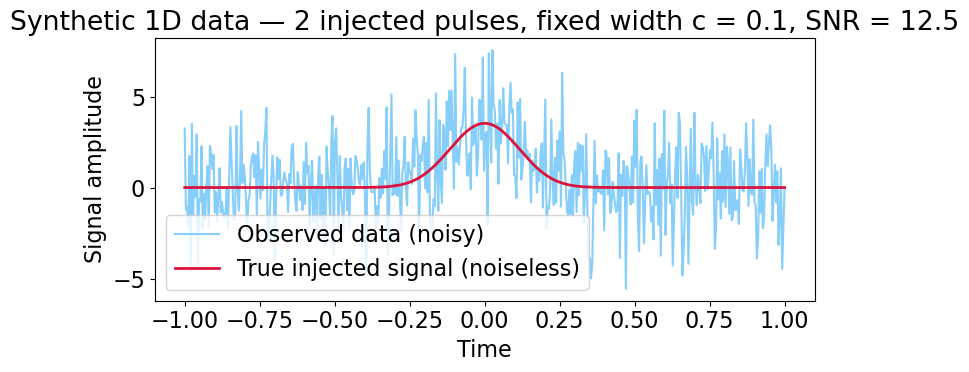

In [2]:
# SECTION 2 — TOY MODEL DEFINITION & SYNTHETIC DATA GENERATION


# 2.1 — CONFIGURATION

# Every experimental knob of this section is collected here, so that a reader can
# reconfigure the whole study without touching the model or generation code.

# [TUNABLE] Fixed Gaussian width c, shared by every pulse (injected AND modelled).
#  Small (e.g. 0.05) : narrow, well-separated pulses, easy to resolve.
#  Large (e.g. 0.40) : broad, overlapping pulses — a far harder model-selection
#                     test, since two overlapping pulses can mimic a single one.
pulse_width_fixed = 0.1 

# [TUNABLE] Resolution of the time axis (number of data points).
number_of_time_samples = 500

# [TUNABLE] Observation window. Section 3 derives the mean-position prior bounds
#  directly from this window, so widening it here automatically widens that prior.
time_axis_lower_bound = -1.0
time_axis_upper_bound = +1.0

# [TUNABLE] The injected ("true") pulses: one [amplitude, mean_position] pair each.
#   The LENGTH of this list is the true model order k the sampler must recover.
#   Any length is valid: [] for pure noise, one pulse, or many. The present study
#   uses two pulses of equal amplitude, placed symmetrically about t = 0.
#   Constraint: every value must lie inside the prior bounds defined in Section 3,
#   otherwise the true solution is unreachable by construction.
true_injected_pulse_parameters = [
    [2.0, -0.05],
    [2.0, +0.05],
]

# [TUNABLE] Standard deviation of the white Gaussian measurement noise.
#   This is the principal difficulty knob of the entire notebook.
#   Small (0.1) : high SNR — the model order is close to visually obvious.
#   Large (1.0) : low SNR  — pulses are buried in noise, which is the regime where
#                 evidence-based model selection genuinely earns its keep.
noise_standard_deviation = 2.0

# 2.2 — MODEL DEFINITION

# Structural: these two functions ARE the physical model. Changing them changes
# the inference problem itself, not merely its configuration.

def single_gaussian_pulse(time_axis, pulse_amplitude, pulse_mean_position):
    """
    Evaluate ONE Gaussian pulse across the full time axis.

        f(t) = pulse_amplitude * exp( -(t - pulse_mean_position)^2 / (2 c^2) )

    The width c (`pulse_width_fixed`) is read from module scope rather than passed
    as an argument, because it is identical and fixed for every pulse. This is
    precisely what reduces the per-pulse dimensionality to 2.

    Returns
    -------
    pulse_values : np.ndarray, shape (number_of_time_samples,)
    """
    pulse_values = pulse_amplitude * np.exp(
        -((time_axis - pulse_mean_position) ** 2) / (2 * pulse_width_fixed ** 2)
    )
    return pulse_values


def combine_all_pulses(time_axis, list_of_pulse_parameter_pairs):
    """
    Sum an ARBITRARY number of Gaussian pulses into one noiseless model signal.

    This function is what makes the problem trans-dimensional in practice: its
    interface is unchanged whether it receives zero pulses or twelve.

    Parameters
    ----------
    time_axis : np.ndarray, shape (number_of_time_samples,)
    list_of_pulse_parameter_pairs : iterable of (pulse_amplitude, pulse_mean_position)
        One entry per ACTIVE pulse. Accepts a list of pairs or a (k, 2) array.
        An EMPTY input returns the zero signal — this is exactly how the
        "no signal" hypothesis (k = 0) is evaluated analytically in Section 5.

    Returns
    -------
    combined_signal : np.ndarray, shape (number_of_time_samples,)
    """
    # Blank canvas matching the shape and dtype of the time axis.
    combined_signal = np.zeros_like(time_axis)

    # Superpose one pulse at a time onto the running total.
    for single_pulse_parameter_pair in list_of_pulse_parameter_pairs:
        pulse_amplitude, pulse_mean_position = single_pulse_parameter_pair
        combined_signal += single_gaussian_pulse(
            time_axis, pulse_amplitude, pulse_mean_position
        )

    return combined_signal


# 2.3 — DERIVED QUANTITIES

# [DERIVED] The discrete time grid on which everything is evaluated.
time_axis = np.linspace(
    time_axis_lower_bound, time_axis_upper_bound, number_of_time_samples
)

# [DERIVED] The true model order, read straight off the injection list is_usable that it
# can never fall out of sync with the pulses actually injected.
true_number_of_pulses = len(true_injected_pulse_parameters)

# [DERIVED] The clean signal, prior to the addition of any noise.
noiseless_injected_signal = combine_all_pulses(
    time_axis, true_injected_pulse_parameters
)


# 2.4 — DATA GENERATION  (executes once; guarded against accidental re-runs)

# The guard is essential. Without it, every re-execution of this cell would draw a
# NEW noise realisation, silently changing the dataset underneath results already
# computed in later sections. To resample deliberately — for instance after
# changing `noise_standard_deviation` — run `del observed_data` first.

if 'observed_data' not in locals():

    measurement_noise = noise_standard_deviation * np.random.randn(number_of_time_samples)
    observed_data = noiseless_injected_signal + measurement_noise

    print("Generated observed_data ONCE (RNG seeded in Section 1).")
    print(f"  True number of injected pulses : k = {true_number_of_pulses}")
    print(f"  Fixed pulse width c            : {pulse_width_fixed}")
    print(f"  Noise standard deviation       : {noise_standard_deviation}")

else:

    print("observed_data already exists in memory — SKIPPING regeneration.")


# 2.5 — DIAGNOSTICS

# Optimal (matched-filter) signal-to-noise ratio of the injection:

# SNR = sqrt( sum_t s(t)^2 ) / sigma_n
# This is the highest SNR any analysis could extract, attainable only if the true
# waveform were known exactly. It is the single number quantifying how hard this
# particular dataset is: SNR of order 10 or more is comfortable, whereas SNR of a
# few is the low-SNR regime this thesis is ultimately concerned with.
optimal_matched_filter_snr = (
    np.sqrt(np.sum(noiseless_injected_signal ** 2)) / noise_standard_deviation
)
print(f"\nOptimal matched-filter SNR of the injection: {optimal_matched_filter_snr:.2f}")

# Visual check: does the noisy data plausibly conceal the injected signal?
plt.figure(figsize=(8, 4))
plt.plot(time_axis, observed_data,
         color="lightskyblue", label="Observed data (noisy)")
plt.plot(time_axis, noiseless_injected_signal,
         color="crimson", lw=2, label="True injected signal (noiseless)")
plt.xlabel("Time")
plt.ylabel("Signal amplitude")
plt.title(f"Synthetic 1D data — {true_number_of_pulses} injected pulses, "
          f"fixed width c = {pulse_width_fixed}, "
          f"SNR = {optimal_matched_filter_snr:.1f}")
plt.legend()
plt.tight_layout()
plt.show()

## Section 3 — Prior Bounds & Prior Distribution Object

### What a prior means here

Each **active** pulse carries two parameters, and we need a prior probability
density over them. We assume the two are independent, so the joint prior factorises:

$$
\pi(A_i, \mu_i) = \pi(A_i)\,\pi(\mu_i)
$$

Both factors are taken to be uniform:

- $A_i \sim \mathcal{U}(A_{\min}, A_{\max})$ — the amplitude is equally likely
  anywhere within a plausible range.
- $\mu_i \sim \mathcal{U}(t_{\min}, t_{\max})$ — the pulse centre may lie anywhere
  inside the observation window, and nowhere outside it.

Restricting $\mu_i$ to the observation window is not an arbitrary convenience: a
pulse centred outside the window contributes almost nothing to the data and its
parameters would be unidentifiable, so admitting that region would inflate the
prior volume without adding any recoverable information.

A note on the lower amplitude bound. Allowing $A_{\min} = 0$ permits pulses of
vanishing amplitude, and such a pulse is observationally indistinguishable from no
pulse at all: a $k$-pulse model containing one zero-amplitude component produces
exactly the same signal as the corresponding $(k-1)$-pulse model. This introduces a
degeneracy *between model orders*, which is precisely the quantity being inferred.
Enforcing a strictly positive $A_{\min}$ removes it, at the cost of assuming a
minimum detectable pulse strength.

### Why `ProbDistContainer` rather than a raw dictionary

Eryn's `EnsembleSampler` expects `priors` to map each **branch name** to a
`ProbDistContainer` **object**, not to a bare dictionary of `uniform_dist` objects.
The container:

- Bundles a `{parameter_index: distribution}` mapping into a single object.
- Exposes `.rvs(size=...)`, which draws random samples — used to initialise the live
  points in Section 6 and to refill inactive leaf slots in Section 8.
- Exposes `.logpdf(x)`, which evaluates $\log \pi(x)$. Eryn calls this internally
  every time it needs the prior probability of a proposed point, for both in-model
  Gaussian moves and reversible-jump birth/death moves.

The distinction matters because the sampler must *repeatedly* draw from and
evaluate the prior. A plain pair of numbers cannot do either; only a distribution
object can. Passing the raw dictionary would leave Eryn without the required
interface at the branch level.

### Parameter indexing convention

Within the `"gauss"` branch, the integer keys `0` and `1` state which prior belongs
to which column of the `(..., ndim)` coordinate array:

- key `0` → `pulse_amplitude` (column 0)
- key `1` → `pulse_mean_position` (column 1)

This ordering must match the unpacking order used in `single_gaussian_pulse`
(Section 2) and in the log-likelihood (Section 4) exactly. A mismatch is among the
most damaging silent bugs possible in an Eryn project: amplitudes would be sampled
as though they were time positions, the code would run to completion without
raising anything, and every result would be wrong.

In [3]:
# SECTION 3 - PRIOR BOUNDS AND PRIOR DISTRIBUTION OBJECT

from eryn.prior import ProbDistContainer   # wraps per-parameter distributions into one object Eryn can call

# Every pulse in this model carries 2 parameters, amplitude and mean position,
# so exactly two priors are required, one per parameter.


# 3.1 - Numerical bounds of each prior

# [TUNABLE] Amplitude prior bounds. Chosen broadly around the injected amplitudes,
#   so that the prior is uninformative without being physically absurd.

#   On the lower bound specifically: setting amplitude_min = 0.0 admits pulses of
#   vanishing amplitude, which are indistinguishable from no pulse at all. A model
#   with k pulses, one of which has A = 0, reproduces the (k-1)-pulse signal
#   exactly, which blurs the boundary between adjacent model orders. 

#   Widening the bounds enlarges the prior volume, which strengthens the Occam
#   penalty applied to higher-k models and generally slows convergence.
#   The bounds MUST contain the injected amplitudes, or the true solution is
#   unreachable by construction.
amplitude_min = 0.0
amplitude_max = 5.0

# [DERIVED] Mean-position prior bounds, taken directly from the observation window
#   defined in Section 2. Changing the window there propagates here automatically.
#   To impose a deliberately narrower prior on position, set these by hand instead.
mean_position_min = time_axis.min()
mean_position_max = time_axis.max()


# 3.2 - Name of this model component

# Eryn organises trans-dimensional models into named "branches", each branch being
# one TYPE of object that may appear a variable number of times. This model has a
# single type, the Gaussian pulse, hence a single branch named "gauss". Introducing
# a second inferred component, for instance an unknown noise level, would add a
# second branch here.

# The string itself is arbitrary, but it is used as a dictionary key in the priors,
# the branch structure dictionaries (Section 5), the sampler (Section 7) and every
# State object (Section 8). It must be spelled identically in all of them.
branch_names = ["gauss"]


# 3.3 - Build the ProbDistContainer for the "gauss" branch

# uniform_dist(a, b) returns a DISTRIBUTION OBJECT rather than a pair of numbers.
# It wraps the interval [a, b] so that Eryn can later call:
#     .rvs()      -> draw a sample uniformly from [a, b]
#     .logpdf(x)  -> return log( 1 / (b - a) ) for a <= x <= b, and -inf otherwise
#
# An object is required, not a tuple, because the sampler must repeatedly sample
# from and evaluate the prior throughout the MCMC and RJ-MCMC steps.

# Key convention: {column_index_in_coords_array: distribution}
#   key 0 -> pulse_amplitude
#   key 1 -> pulse_mean_position
gauss_branch_prior_dict = {
    0: uniform_dist(amplitude_min, amplitude_max),
    1: uniform_dist(mean_position_min, mean_position_max),
}

# ProbDistContainer combines the two per-parameter distributions into ONE joint
# prior for a single leaf (a single pulse), so that both parameters can be sampled
# or evaluated together in one call:
#     priors["gauss"].rvs(size=(n,))   -> array of shape (n, 2)
#     priors["gauss"].logpdf(x)        -> log-prior density, x of shape (n, 2)

# Required structure, which Eryn assumes without checking:
#     priors            -> dict with one entry per branch
#     priors["gauss"]   -> a ProbDistContainer object, never a raw dict

# Handing Eryn `gauss_branch_prior_dict` directly would fail, because the sampler
# needs the .rvs()/.logpdf() interface at the BRANCH level, not merely at the level
# of individual parameters.
priors = {
    "gauss": ProbDistContainer(gauss_branch_prior_dict)   # consumed by the EnsembleSampler in Section 7
}


# 3.4 - [OPTIONAL] Confirm the injected truth lies inside the prior support

# If any injected value falls outside these bounds, the true solution has zero prior
# probability and the sampler cannot recover it no matter how long it runs. This is
# a configuration error rather than a sampling failure, and it is worth catching
# here rather than diagnosing it from a puzzling posterior in Section 10.
for pulse_index, (injected_amplitude, injected_mean_position) in enumerate(true_injected_pulse_parameters):

    assert amplitude_min <= injected_amplitude <= amplitude_max, (
        f"Injected pulse {pulse_index} has amplitude {injected_amplitude}, "
        f"outside the prior range [{amplitude_min}, {amplitude_max}].")

    assert mean_position_min <= injected_mean_position <= mean_position_max, (
        f"Injected pulse {pulse_index} has mean position {injected_mean_position}, "
        f"outside the prior range [{mean_position_min}, {mean_position_max}].")

print("Prior support verified: all injected pulses lie inside the prior bounds.")
print(f"  Amplitude prior     : U({amplitude_min}, {amplitude_max})")
print(f"  Mean position prior : U({mean_position_min:.2f}, {mean_position_max:.2f})")

Prior support verified: all injected pulses lie inside the prior bounds.
  Amplitude prior     : U(0.0, 5.0)
  Mean position prior : U(-1.00, 1.00)


## Section 4 — Log-Likelihood Function & the Nested Sampling Hard Constraint

### The true physical likelihood

Assuming stationary, white, Gaussian measurement noise of known standard deviation
$\sigma_n$, the likelihood of the observed data given a set of active pulses is

$$
\log \mathcal{L}(\theta) = -\frac{1}{2}\sum_{j=1}^{N_t}
\left(\frac{d_j - s(t_j;\theta)}{\sigma_n}\right)^2
$$

where $d_j$ is the datum at time sample $j$ and $s(t_j;\theta)$ is the model signal
built in Section 2 by summing the active pulses. This is the standard Gaussian-noise
log-likelihood used throughout gravitational-wave data analysis.

The additive normalisation constant $-\frac{N_t}{2}\log(2\pi\sigma_n^2)$ is omitted.
Because $N_t$ and $\sigma_n$ are fixed and identical for every model considered, this
constant shifts every log-likelihood by the same amount and therefore cancels
exactly in likelihood ratios, Bayes factors, and posterior weights. It does not
cancel in the *absolute* value of $\log\mathcal{Z}$ reported in Section 10, which is
consequently offset by that same constant relative to a fully normalised
calculation. This matters only when comparing $\log\mathcal{Z}$ against an external
implementation, never when comparing models within this notebook.

### Why two likelihood functions are needed

**`true_gaussian_log_likelihood`** computes the physical $\log\mathcal{L}(\theta)$
above. It is the quantity recorded for every live and dead point, and the quantity
from which the evidence integral is ultimately assembled in Section 10. Eryn never
sees it.

**`eryn_constrained_log_likelihood`** is the function actually handed to Eryn's
`EnsembleSampler`. It carries the hard constraint:

$$
\log\mathcal{L}_{\text{constrained}}(\theta) =
\begin{cases}
0 & \text{if } \log\mathcal{L}(\theta) > \log\mathcal{L}_0 \\
-\infty & \text{otherwise}
\end{cases}
$$

### Why zero, rather than the real likelihood, when the constraint is satisfied

This is the point on which the whole hybrid design turns.

Nested Sampling requires a new live point drawn **uniformly from the prior,
restricted to the region** $\{\theta : \mathcal{L}(\theta) > \mathcal{L}_0\}$. It
explicitly does *not* want the sampler to drift toward higher-likelihood points
within that region: the algorithm's compression estimate assumes every point inside
the constrained shell is weighted by the prior alone.

Returning the real log-likelihood would make the Metropolis-Hastings acceptance
ratio target $\pi(\theta)\mathcal{L}(\theta)$ restricted to the shell, so the walker
would continue to climb the likelihood surface inside the allowed region and the
resulting point would not be a uniform prior draw.

Returning a constant instead removes any such gradient. With a symmetric proposal
and a uniform prior, the acceptance probability collapses to

$$
\alpha = \min\!\left(1,\ \frac{\pi(\theta')}{\pi(\theta)}
\cdot \mathbb{1}\!\left[\mathcal{L}(\theta') > \mathcal{L}_0\right]\right)
$$

that is, a pure prior random walk subject to a boolean pass/fail gate, which is
exactly the operation Nested Sampling specifies. The specific value $0$ is a
convention: any constant would give the same acceptance ratio, since it cancels
between numerator and denominator. In linear space it corresponds to a likelihood
of $1$, flat everywhere inside the shell.

(`log_like_fn_gauss_pulse_2`), is the standard construction in the Nested
Sampling literature: Skilling notes that sampling within a likelihood constraint
may be performed by MCMC over the prior, accepting only points of greater
likelihood.

### How the threshold is updated

`current_logL0_threshold` is not a constant. The outer Nested Sampling loop raises
it at every iteration, as the worst live point is discarded. Since Eryn calls the
likelihood internally, deep inside `run_mcmc`, a new Python float cannot be passed
in as an argument without rebuilding the sampler each iteration.

A one-element NumPy array solves this. Rebinding a float creates a new object, and
a function that captured the old one by closure would never see the change. Writing
into `array[0]` mutates the contents of the *same* object, so the closure reads the
updated value on its very next call. Eryn therefore always sees the current
threshold, and the outer loop never touches Eryn's internals.

### On the strict inequality

A candidate is accepted only when $\log\mathcal{L}(\theta) > \log\mathcal{L}_0$;
equality is rejected. The point defining $\mathcal{L}_0$ is being discarded
precisely because it is the worst live point, so its replacement must be strictly
better. Admitting equality would allow a replacement identical in likelihood to the
point it replaces, violating the strict-improvement invariant that the correctness
assertion in Section 8 enforces.

The strict comparison also handles non-finite values correctly by construction: if
$\log\mathcal{L}(\theta)$ evaluates to NaN, the comparison returns false and the
point is rejected, which is the desired behaviour.

In [4]:
# SECTION 4 - LOG-LIKELIHOOD FUNCTIONS AND THE NESTED SAMPLING HARD CONSTRAINT


# 4.1 - The true Gaussian-noise log-likelihood

def true_gaussian_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):
    """
    Physical log-likelihood of the data given a set of active pulses.

    This is the quantity recorded for every live and dead point, and the quantity
    from which the evidence integral is built in Section 10. Eryn never calls it
    directly; it only ever sees the constrained wrapper defined in 4.3.

        logL = -0.5 * sum_j [ (d_j - s(t_j)) / sigma_n ]^2

    The additive constant -N/2 * log(2 pi sigma_n^2) is omitted. It is identical for
    every model compared here, so it cancels in all ratios and weights, but it does
    offset the absolute logZ reported in Section 10.

    Parameters
    ----------
    pulse_parameters_array : np.ndarray, shape (n_active_pulses, 2)
        Each row is [pulse_amplitude, pulse_mean_position] for ONE active pulse.
        n_active_pulses may be 0, in which case the model signal is identically
        zero and this returns the likelihood of the pure-noise hypothesis.
    time_axis : np.ndarray, shape (number_of_time_samples,)
    observed_data : np.ndarray, shape (number_of_time_samples,)
    noise_standard_deviation : float

    Returns
    -------
    log_likelihood_value : float
    """

    model_signal = combine_all_pulses(time_axis, pulse_parameters_array)

    # Residual, expressed in units of noise standard deviations.
    residual = (observed_data - model_signal) / noise_standard_deviation

    log_likelihood_value = -0.5 * np.sum(residual ** 2)

    return log_likelihood_value


# 4.2 - The mutable threshold shared with Eryn

# The minimum acceptable likelihood rises at every Nested Sampling iteration.

# A plain float would not work here. Rebinding a float creates a NEW object, and
# the constrained likelihood below captures this name by closure, so it would keep
# reading the original value and never observe the update. A one-element array is a
# mutable container: writing into element [0] changes the contents of the SAME
# object, and the closure therefore sees the new value on its very next call.

# The safety guard follows the same reasoning as `observed_data` in Section 2:
# re-running this cell mid-run must not silently reset the threshold to -inf and
# invalidate the compression accumulated so far.

if 'current_logL0_threshold' not in locals():

    # Starting at -inf means the first iteration accepts any point whatsoever,
    # which corresponds to the full prior volume being available (X = 1).
    current_logL0_threshold = np.array([-np.inf])

    print("Initialized current_logL0_threshold = -inf (full prior volume available).")

else:
    print(f"current_logL0_threshold already exists ({current_logL0_threshold[0]:.4f}) "
          f"- SKIPPING re-initialization.")


# 4.3 - The constrained log-likelihood Eryn actually calls

def eryn_constrained_log_likelihood(pulse_parameters_array, time_axis, observed_data, noise_standard_deviation):
    """
    Pass/fail gate handed to Eryn's EnsembleSampler in place of a real likelihood.

    Returns a constant 0.0 for every point inside the current constrained shell and
    -inf for every point outside it. The likelihood surface Eryn explores is
    therefore perfectly flat wherever sampling is permitted, so the walker performs
    a pure prior random walk rather than climbing toward the peak. That flat walk is
    exactly the "sample from the prior subject to logL > logL0" operation Nested
    Sampling requires.

    The comparison is strict. A point whose likelihood merely equals the threshold
    is rejected, as is any point whose likelihood evaluates to NaN, since NaN fails
    every comparison.

    The signature must match the `args` passed to EnsembleSampler in Section 7:
    args = [time_axis, observed_data, noise_standard_deviation], supplied after
    pulse_parameters_array. Note that current_logL0_threshold is deliberately absent
    from that list; it is reached by closure, not passed as an argument.

    Returns
    -------
    constrained_log_likelihood_value : float, either 0.0 or -np.inf
    """

    true_log_likelihood_value = true_gaussian_log_likelihood(
        pulse_parameters_array, time_axis, observed_data, noise_standard_deviation
    )

    if true_log_likelihood_value > current_logL0_threshold[0]:
        # Inside the shell: flat, so no direction within the shell is preferred.
        constrained_log_likelihood_value = 0.0

    else:
        # Outside the shell, or non-finite: zero probability, never accepted.
        constrained_log_likelihood_value = -np.inf

    return constrained_log_likelihood_value


# 4.4 - [OPTIONAL] Evaluate both functions at the injected truth

# Feeding the exact injected parameters into the likelihood is the cheapest possible
# check that the model, the data, and the likelihood are mutually consistent, and it
# costs nothing compared with discovering an error after a multi-hour run.

# At the true parameters the residual is precisely the injected noise realisation,
# so each term (d_j - s_j)/sigma_n is a standard normal draw and the expected value
# of the sum of their squares is N. The log-likelihood should therefore sit near
# -N/2, fluctuating by order sqrt(N/2) between noise realisations. A value far from
# this indicates a genuine bug rather than bad luck.

true_log_likelihood_at_injected_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)

expected_log_likelihood_at_truth = -0.5 * number_of_time_samples
expected_log_likelihood_scatter = np.sqrt(0.5 * number_of_time_samples)

print(f"\nTrue logL at injected truth : {true_log_likelihood_at_injected_truth:.2f}")
print(f"  Expected                  : {expected_log_likelihood_at_truth:.1f} "
      f"+/- {expected_log_likelihood_scatter:.1f}")

# The omitted normalisation constant, reported only so that the absolute logZ of
# Section 10 can be reconciled with a fully normalised external calculation.
omitted_log_likelihood_normalisation = -0.5 * number_of_time_samples * np.log(
    2 * np.pi * noise_standard_deviation ** 2
)
print(f"  Omitted normalisation const : {omitted_log_likelihood_normalisation:.2f} "
      f"(constant, cancels in all ratios)")

# The constrained function returns 0.0 only while the threshold is still -inf, which
# is the case on a clean run of this notebook from the top. Re-running this cell
# after Section 9 has begun will legitimately print -inf, because the threshold has
# by then risen above the likelihood of the injected truth. That is correct
# behaviour, not a failure.
constrained_log_likelihood_at_injected_truth = eryn_constrained_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis, observed_data, noise_standard_deviation
)

print(f"\nConstrained logL at injected truth : {constrained_log_likelihood_at_injected_truth}")
print(f"  Current threshold                : {current_logL0_threshold[0]}")
print("  (0.0 expected on a clean run; -inf is correct if the run has already started)")

Initialized current_logL0_threshold = -inf (full prior volume available).

True logL at injected truth : -244.95
  Expected                  : -250.0 +/- 15.8
  Omitted normalisation const : -806.04 (constant, cancels in all ratios)

Constrained logL at injected truth : 0.0
  Current threshold                : -inf
  (0.0 expected on a clean run; -inf is correct if the run has already started)


## Section 5 — Branch Structure: `nleaves_min` and `nleaves_max`

### What the branch structure controls

This section states the rules of the trans-dimensional search space to Eryn:

- How many parameters one pulse carries, via `ndims_per_branch["gauss"]`. This is
  where the `pulse_ndim = 2` simplification of Section 2 formally enters the Eryn
  API: amplitude and mean position, with the width held fixed.
- The smallest number of pulses the RJ-MCMC may explore, via `nleaves_min["gauss"]`.
- The largest number it may explore, via `nleaves_max["gauss"]`.

Eryn calls each individual pulse a **leaf** of the `"gauss"` branch. The number of
active leaves is the model order $k$, and it is the quantity this entire thesis is
built to infer.

### Why `nleaves_min` is 1 rather than 0, and how $k=0$ is still handled

The pure-noise hypothesis must remain available. Without it the analysis would only
answer "how many pulses, given that there is at least one", which is a weaker
question than the model-selection problem being posed.

It is nonetheless not implemented by setting `nleaves_min["gauss"] = 0`. Eryn
returns a NaN log-likelihood for a walker holding zero active leaves across all
branches, and a single NaN propagates through the ensemble and corrupts the run.
The hypothesis is therefore split across two computational paths:

- Eryn's RJ-MCMC explores $k \geq 1$ only, under `nleaves_min["gauss"] = 1`.
- The $k = 0$ hypothesis is evaluated **analytically, entirely outside Eryn**. A
  model with zero free parameters has nothing to integrate over, so its evidence is
  simply its likelihood, evaluated once here as `log_evidence_no_signal_model`.

Section 10 recombines the two into a single posterior over $k$, so the full
comparison is recovered. The split is a workaround for an implementation defect,
not a modelling assumption, and it does not bias the comparison provided the
evidences are combined with the correct discrete prior weights.

That last proviso deserves to be stated explicitly rather than assumed. The
combination performed in Section 10.4 assigns equal prior odds to "no signal" and
"signal present", and spreads the latter uniformly over $k \in \{1, \dots,
n_{\max}\}$. The implied prior on model order is therefore

$$
P(k=0) = \tfrac{1}{2}, \qquad
P(k=i) = \frac{1}{2\,n_{\max}} \quad \text{for } i \geq 1
$$

which is a detection-style prior, deliberately favouring neither presence nor
absence of signal. It is not the same as a prior uniform over $\{0, \dots,
n_{\max}\}$, and reporting which convention was used is part of reporting the
result.

### Choosing `nleaves_max`

The ceiling must exceed the true number of injected pulses, or the correct answer
lies outside the search space and cannot be recovered even in principle. The
assertion at the end of this section enforces exactly that.

Setting it far higher is not free. Every leaf slot occupies memory in the padded
`(..., nleaves_max, ndim)` arrays whether or not it is active, so the cost is paid
on every point at every iteration. More importantly, a uniform prior over $k \in
\{1, \dots, n_{\max}\}$ spreads the same total prior probability across more values,
so each individual $k$ starts with less prior mass and the model-order posterior
takes longer to concentrate.

A useful diagnostic appears in Section 9.6: if a large fraction of dead points pile
up at exactly $k = n_{\max}$, the ceiling is binding and should be raised.

### Why these must be dictionaries

Eryn expects `{branch_name: value}` dictionaries for both quantities, because a
model may in general contain several branches, each with its own dimensionality and
leaf-count limits. This model has only one branch, but the dictionary form is still
required. Passing a bare integer in place of `{"gauss": 2}` produces a shape
mismatch deep inside the sampler rather than a clear error at the point of use,
which is why both are checked explicitly below.

In [5]:
# SECTION 5 - BRANCH STRUCTURE SETUP


# 5.1 - Per-pulse dimensionality

# Formal Eryn-API expression of the simplification introduced in Section 2: each
# "gauss" leaf, meaning each individual pulse, carries exactly 2 free parameters,
# pulse_amplitude and pulse_mean_position. The width is fixed and never sampled.

# Raising this to 3 to sample the width as well is a structural change, not a knob:
# it would require matching edits to single_gaussian_pulse (Section 2), to
# gauss_branch_prior_dict (Section 3, an additional key 2), and to every place the
# coordinate columns are unpacked.
pulse_ndim = 2

ndims_per_branch = {"gauss": pulse_ndim}


# 5.2 - Allowed range of active pulses

# nleaves_min is 1 by necessity, not by choice. Eryn returns a NaN log-likelihood
# for a walker with zero active leaves in every branch, and that NaN spreads through
# the ensemble. The k=0 hypothesis is therefore not abandoned but computed
# analytically below, outside Eryn entirely.
nleaves_min = {"gauss": 1}

# [TUNABLE] Ceiling on the number of pulses the sampler may consider.
#   Must exceed the true injected count, which the assertion in 5.3 enforces.
#   Raising it costs memory in the padded arrays and dilutes the discrete prior over
#   k, slowing convergence of the model-order posterior. Lowering it below the truth
#   makes the correct answer unreachable.
#   Section 9.6 reports whether this ceiling is binding in practice.
nleaves_max = {"gauss": 8}


# The analytic evidence of the k = 0 model. With zero free parameters there is
# nothing to integrate over, so the evidence equals the likelihood evaluated at the
# single point the model permits: the zero signal.

# An empty (0, 2) array is passed, which combine_all_pulses returns as the zero
# signal, so this reuses the same likelihood code path as every other point rather
# than duplicating the formula.
log_evidence_no_signal_model = true_gaussian_log_likelihood(
    np.empty((0, pulse_ndim)), time_axis, observed_data, noise_standard_deviation
)

print(f"Analytic log-evidence of the k=0 (no signal) model: {log_evidence_no_signal_model:.4f}")


# 5.3 - [OPTIONAL] Catch structural mistakes before they reach the sampler

assert isinstance(ndims_per_branch, dict), \
    "ndims_per_branch must be a dict, e.g. {'gauss': 2}. Eryn requires the branch-keyed form."

assert isinstance(nleaves_max, dict), \
    "nleaves_max must be a dict, e.g. {'gauss': 8}. Eryn requires the branch-keyed form."

assert nleaves_min["gauss"] >= 1, \
    ("nleaves_min must be at least 1. A walker with zero active leaves triggers a NaN "
     "log-likelihood inside Eryn; the k=0 hypothesis is handled analytically instead.")

assert nleaves_min["gauss"] <= nleaves_max["gauss"], \
    "nleaves_min cannot exceed nleaves_max, or the allowed range of k would be empty."

assert nleaves_max["gauss"] >= true_number_of_pulses, \
    (f"nleaves_max = {nleaves_max['gauss']} is smaller than the true injected pulse count "
     f"({true_number_of_pulses}). The correct answer lies outside the search space and "
     f"could never be recovered. Increase nleaves_max.")

print(f"Branch 'gauss': ndim = {ndims_per_branch['gauss']} "
      f"(pulse_amplitude, pulse_mean_position)")
print(f"  Explored range of k : [{nleaves_min['gauss']}, {nleaves_max['gauss']}] "
      f"via RJ-MCMC, plus k = 0 handled analytically")
print(f"  True injected count : {true_number_of_pulses}")

Analytic log-evidence of the k=0 (no signal) model: -328.1785
Branch 'gauss': ndim = 2 (pulse_amplitude, pulse_mean_position)
  Explored range of k : [1, 8] via RJ-MCMC, plus k = 0 handled analytically
  True injected count : 2


## Section 6 — Initializing Live Points: Coordinates and Active-Leaf Masks

### What is being built

In this architecture the Nested Sampling live points occupy the role that walkers
occupy in ordinary Eryn or emcee usage. Two padded arrays are required per branch:

- `live_point_coordinates["gauss"]`, of shape `(ntemps, nlive, nleaves_max, ndim)`,
  holding the $(A_i, \mu_i)$ values of every possible leaf slot, active or not.
- `live_point_active_leaf_mask["gauss"]`, of shape `(ntemps, nlive, nleaves_max)`
  and boolean, where `True` marks a slot representing a real active pulse and
  `False` marks padding that the likelihood and prior ignore.

The padded layout is what allows a variable number of pulses to live inside
fixed-shape NumPy arrays: the arrays are always sized for the maximum, and the mask
determines how much of that capacity is currently in use.

### Initialising from the full prior

A tempting shortcut is to seed every live point close to the injected truth, which
converges faster and is useful when testing that the machinery runs at all. It is
not done here.

Nested Sampling requires the initial live point population to be drawn
independently from the joint prior, because the first likelihood contour is defined
by the worst of those points and the entire compression estimate follows from that
starting configuration. In a trans-dimensional setting the joint prior has two
parts, drawn in order:

1. The **discrete** part: the number of active pulses for each live point, drawn
   uniformly from $\{n_{\min}, \dots, n_{\max}\}$. Section 5 fixes $n_{\min} = 1$,
   since $k = 0$ is handled analytically and lies outside this population entirely.
2. The **continuous** part: for each active pulse, its $(A_i, \mu_i)$ drawn from
   `priors["gauss"]`.

Seeding near the truth would converge faster while silently supplying the sampler
with information about the answer, which invalidates the evidence integral. It
would also conceal defects in the reversible-jump birth and death moves, since the
sampler would never be required to discover the correct model order for itself.
Starting from the prior means the model order visible in the Section 9 diagnostics
is genuinely learned rather than assumed.

### Why inactive slots are filled rather than left as NaN

Inactive leaf values never reach the likelihood, which receives only the
active-leaf sub-array. They are nonetheless filled with valid prior draws rather
than left undefined, because Eryn's reversible-jump birth moves activate an
existing inactive slot and may read its current contents before overwriting them.
A NaN sitting in padding can therefore enter live arithmetic through a birth move
and spread silently, since NaN propagates through every operation without raising.
Filling every slot removes the failure mode rather than relying on it never being
triggered. Section 8 repeats the same refill after every Eryn call, for the same
reason.

### On the arrangement of active slots

This initialisation activates the first $k$ slots of each live point, so active
leaves begin contiguous. They do not remain so: a death move can deactivate any
slot, leaving the active set scattered across the array. Every subsequent operation
therefore selects active leaves by boolean mask rather than by slicing the first
$k$ entries, and code that assumed contiguity would fail silently rather than
raising.

### On re-running this cell

These draws seed the entire run, so the cell is guarded. Re-executing it mid-analysis
would replace the live population while the dead-point archive and the likelihood
threshold continued to reflect the previous one, leaving the two irreconcilable.

In [6]:
# SECTION 6 - INITIALIZING LIVE POINTS (COORDINATES AND ACTIVE-LEAF MASKS)


# 6.1 - Population sizes

# [TUNABLE] Number of temperatures. Parallel tempering runs several ensembles at
#   progressively flattened likelihoods so that walkers can escape local maxima. It
#   is unnecessary for a problem this size, so a single cold chain is used.
#   Raising this changes the leading dimension of every live-point array.
number_of_temperatures = 1

# [TUNABLE] Number of Nested Sampling live points.
#   This is the principal accuracy-versus-runtime knob of the whole run. The
#   evidence uncertainty scales as sqrt(H / nlive), so quadrupling the population
#   halves the error bar, at roughly four times the cost per unit of compression.
number_of_live_points = 25 * pulse_ndim * nleaves_max["gauss"] // 2


# 6.2 - Draw the initial population from the prior, once

# Both arrays are checked, not just the coordinates. Deleting only one of them would
# otherwise skip this block and leave the other missing, surfacing as a NameError in
# a later section rather than here.
if 'live_point_coordinates' not in locals() or 'live_point_active_leaf_mask' not in locals():

    # Step 1: the discrete part of the prior, one draw of k per live point.
    
    # np.random.randint excludes its upper bound, hence the +1: the draw covers
    # nleaves_min through nleaves_max inclusive. The lower bound is 1 rather than 0
    # because k = 0 is handled analytically in Section 5 and never appears in this
    # population.
    number_of_active_pulses_per_live_point = np.random.randint(
        low=nleaves_min["gauss"],
        high=nleaves_max["gauss"] + 1,
        size=(number_of_temperatures, number_of_live_points),
    )

    # Step 2: allocate the padded coordinate array,
    # shape (ntemps, nlive, nleaves_max, ndim).
    
    # Every live point is given the full nleaves_max capacity regardless of how many
    # pulses it actually uses. np.empty reserves memory without initialising it, so
    # the contents are arbitrary until Step 4 overwrites every slot.
    live_point_coordinates = {
        "gauss": np.empty((
            number_of_temperatures,
            number_of_live_points,
            nleaves_max["gauss"],
            ndims_per_branch["gauss"],
        ))
    }

    # Step 3: allocate the boolean mask, shape (ntemps, nlive, nleaves_max).
    
    # This is the array Eryn calls `inds`. Every switch starts False, and Step 4
    # turns on exactly as many as each live point drew in Step 1.
    live_point_active_leaf_mask = {
        "gauss": np.zeros((
            number_of_temperatures,
            number_of_live_points,
            nleaves_max["gauss"],
        ), dtype=bool)
    }

    # Step 4: fill every slot with a valid prior draw, then activate the first k.
    for temperature_index in range(number_of_temperatures):
        for live_point_index in range(number_of_live_points):

            # How many pulses this particular live point drew in Step 1.
            active_pulse_count_this_live_point = number_of_active_pulses_per_live_point[
                temperature_index, live_point_index
            ]

            # The continuous part of the prior. One independent draw is taken for
            # EVERY slot, not merely the active ones, so that no slot is ever left
            # holding uninitialised memory for a birth move to pick up later.
            # Returned shape is (nleaves_max, ndim).
            prior_draws_for_all_slots = priors["gauss"].rvs(size=(nleaves_max["gauss"],))

            live_point_coordinates["gauss"][temperature_index, live_point_index] = prior_draws_for_all_slots

            # Activate the first k slots. The remaining slots keep their valid but
            # unused values and are ignored entirely while their mask entry is False.
            # This contiguous arrangement holds only at initialisation; after a death
            # move the active set may be scattered, which is why every later operation
            # selects active leaves by mask rather than by slicing.
            live_point_active_leaf_mask["gauss"][
                temperature_index, live_point_index, :active_pulse_count_this_live_point
            ] = True

    print(f"Initialized {number_of_live_points} live points from the full prior "
          f"(no warm start at the injected truth).")

    initial_model_order_counts = np.bincount(
        number_of_active_pulses_per_live_point.flatten(),
        minlength=nleaves_max["gauss"] + 1,
    )
    print(f"  Initial distribution of k across live points: {initial_model_order_counts}")
    print(f"  (indices 0 to {nleaves_max['gauss']}; index 0 is necessarily empty, "
          f"since k = 0 is handled analytically)")

else:
    print("live_point_coordinates already exists - SKIPPING re-initialization.")
    print("  Delete BOTH live_point_coordinates and live_point_active_leaf_mask "
          "to reseed the population.")

Initialized 200 live points from the full prior (no warm start at the injected truth).
  Initial distribution of k across live points: [ 0 18 21 32 32 30 26 21 20]
  (indices 0 to 8; index 0 is necessarily empty, since k = 0 is handled analytically)


## Section 7 — Building the Eryn `EnsembleSampler`

### `nwalkers` is not the live-point count

This is the most easily confused part of the hybrid architecture, so it is worth
stating plainly.

`number_of_live_points` from Section 6 is our own bookkeeping quantity: the size of
the Nested Sampling population, held in plain NumPy arrays that Eryn never sees.
`number_of_walkers` is an Eryn-internal concept: the number of parallel MCMC chains
evolved inside a single call to `run_mcmc`.

Here `number_of_walkers = 1`. At each Nested Sampling iteration the outer loop of
Section 8 discards the worst live point, selects one surviving point at random as a
starting position, hands that single point to Eryn as one walker, asks for a short
constrained random walk, and reads off wherever the walker finished as the
replacement. Exactly one new point is needed per iteration, so exactly one walker is
required.

The `EnsembleSampler` is consequently a reusable tool rather than a container of
state. It is built once here and called repeatedly, with a different starting `State`
each time. The population structure lives entirely in the outer loop.

### Why the object is rebuilt rather than preserved

The sampler is configured from `ndims_per_branch`, `nleaves_min`, `nleaves_max` and
the priors, all fixed at construction time. An object built before any of those
changed would silently continue enforcing the old values, which is the kind of
inconsistency that produces wrong results rather than errors.

Because the run's actual state, the live points, the dead-point archive and the
likelihood threshold, is held in our own arrays and not inside the sampler, nothing
is lost by discarding and rebuilding it. This cell therefore always rebuilds. Note
that the reverse dependency does not hold: re-running Section 6 after changing
`nleaves_max` reshapes the live-point arrays, so a change to Section 5 requires
re-running Sections 6 and 7 together, in that order.

### The `GaussianMove` proposal

Reversible-jump moves change the number of active pulses. Between them, the sampler
also needs a way to explore **within** a fixed dimensionality, refining the amplitude
and position of pulses that are already active. `GaussianMove(cov)` supplies this by
proposing small random-walk steps drawn from $$\mathcal{N}(0, \Sigma)$$ around the
current position, with $\Sigma$ diagonal and one entry per parameter.

The step size is a genuine trade-off rather than a detail. The region the walker is
confined to is the constrained shell

$$
S = \left\lbrace\, \theta \;:\; \mathcal{L}(\theta) > \mathcal{L}_0 \,\right\rbrace
$$

A large step means most proposals land outside $S$ and are rejected, consuming the
step budget without moving. A small step stays inside $S$ but explores it slowly, so
the replacement point remains correlated with the seed it started from, which is
precisely what Nested Sampling requires it not to be.

The trade-off also shifts during the run. The shell contracts continuously as the
threshold rises, so a step size well matched to the early, broad shell will be too
large for the narrow shell near the peak. The clone-fallback fraction reported in
Section 9.5 is the diagnostic for this: a rising fallback rate indicates that Eryn
is increasingly failing to find a valid replacement within its step budget.

### Passing the data through `args`

`args=[time_axis, observed_data, noise_standard_deviation]` is forwarded to every
call as `eryn_constrained_log_likelihood(pulse_parameters_array, *args)`. The order
must match the function signature in Section 4 exactly; a permutation here would
pass arguments into the wrong parameters without raising anything.

`current_logL0_threshold` is deliberately absent from this list. It is a mutable
array reached by closure, so Eryn always reads its current value without it ever
needing to be re-passed. This is what allows the sampler to be built once while the
threshold rises thousands of times.

### `rj_moves=True`

This flag enables the reversible-jump birth and death proposals. Without it the
sampler would explore only within whatever number of active leaves each walker
started with, and the model order would never change. Every live point would remain
permanently fixed at the $k$ it drew during initialisation, the posterior over $k$
would simply reproduce the discrete prior, and the run would complete without error.

In [7]:
# SECTION 7 - BUILDING THE EnsembleSampler OBJECT

from eryn.moves import GaussianMove
from eryn.ensemble import EnsembleSampler


# 7.1 - In-model proposal

# [TUNABLE] Scale of the in-model Gaussian random-walk step, applied to both
#   parameters through a diagonal covariance matrix.

#   Too large : most proposals leave the constrained shell and are rejected, so the
#               walker consumes its step budget without moving.
#   Too small : the walker stays inside the shell but barely explores it, leaving
#               the replacement point correlated with the seed it started from.

#   The appropriate value shrinks as the run progresses and the shell contracts.
#   Section 9.5 reports the clone-fallback fraction, which rises when this step size
#   has become too large for the current shell.

#   The two diagonal entries may be set independently if amplitude and position turn
#   out to require different step scales, by replacing np.ones(...) with an explicit
#   array such as np.array([0.01, 0.001]).
gaussian_move_step_size_scale = 1e-3

gaussian_move_covariance = {
    "gauss": np.diag(np.ones(ndims_per_branch["gauss"])) * gaussian_move_step_size_scale
}

in_model_proposal_move = GaussianMove(gaussian_move_covariance)


# 7.2 - Eryn-internal walker count

# One walker, because one Nested Sampling iteration requires exactly one replacement
# point. This is unrelated to number_of_live_points: the population is maintained by
# the outer loop, not by Eryn. Changing this would require redesigning how Section 8
# selects a seed and reads back a result.
number_of_walkers = 1


# 7.3 - Build the sampler

# Rebuilt unconditionally rather than guarded. The sampler is configured at
# construction from the branch structure and priors, so an object surviving from
# before those were edited would keep enforcing stale values without complaint.
# Nothing is lost by rebuilding, because the run's state lives in our own arrays:
# the live points, the dead-point archive and current_logL0_threshold are all
# external to this object.

# The dependency does not run the other way. Changing nleaves_max in Section 5 also
# reshapes the live-point arrays, so Sections 6 and 7 must both be re-run, in order.
if 'ensemble' in locals():
    del ensemble

ensemble = EnsembleSampler(
    number_of_walkers,
    ndims_per_branch,                            # {"gauss": pulse_ndim}, from Section 5
    eryn_constrained_log_likelihood,             # the pass/fail gate from Section 4, not the true likelihood
    priors,                                      # {"gauss": ProbDistContainer(...)}, from Section 3
    args=[time_axis, observed_data, noise_standard_deviation],   # order must match the likelihood signature
    tempering_kwargs=dict(ntemps=number_of_temperatures),        # single cold chain
    nbranches=len(branch_names),                 # one branch
    branch_names=branch_names,                   # ["gauss"]
    nleaves_max=nleaves_max,                     # from Section 5
    nleaves_min=nleaves_min,                     # from Section 5, at least 1
    moves=in_model_proposal_move,                # within-dimension exploration
    rj_moves=True,                               # birth and death proposals, changing k
)

print("EnsembleSampler built.")
print(f"  Walkers            : {number_of_walkers}")
print(f"  Temperatures       : {number_of_temperatures}")
print(f"  Branch             : {branch_names[0]}, ndim = {ndims_per_branch['gauss']}")
print(f"  Leaf range         : [{nleaves_min['gauss']}, {nleaves_max['gauss']}]")
print(f"  In-model step scale: {gaussian_move_step_size_scale}")


# 7.4 - [OPTIONAL] Confirm the sampler can call our prior and likelihood

# The first live point is passed through the sampler's own interface, which is the
# only way to verify that Eryn, the priors and the constrained likelihood agree on
# array shapes and conventions. A failure here is an interface problem, and it is far
# cheaper to diagnose at this point than from inside a running loop.

# The 0:1 slice retains the walker axis as a length-one dimension. A bare index 0
# would remove it, leaving a 3-D array where the sampler expects
# (ntemps, nwalkers, nleaves_max, ndim).
test_coords = {"gauss": live_point_coordinates["gauss"][:, 0:1, :, :]}
test_inds = {"gauss": live_point_active_leaf_mask["gauss"][:, 0:1, :]}

check_log_prior = ensemble.compute_log_prior(test_coords, inds=test_inds)

check_log_like = ensemble.compute_log_like(
    test_coords, inds=test_inds, logp=check_log_prior
)[0]

expected_shape = (number_of_temperatures, 1)

assert check_log_prior.shape == expected_shape, \
    f"log_prior shape {check_log_prior.shape} does not match expected {expected_shape}."

assert check_log_like.shape == expected_shape, \
    f"log_like shape {check_log_like.shape} does not match expected {expected_shape}."

# The test point was drawn from the prior in Section 6, so its prior density must be
# finite. An infinite value would mean the point lies outside its own prior support,
# and would also invalidate the likelihood check below.
assert np.all(np.isfinite(check_log_prior)), \
    "Test live point has non-finite log-prior, so it lies outside the prior support."

# The constrained likelihood is a pass/fail gate and can return nothing else. Any
# other value means Eryn is not calling the function from Section 4 as intended.
assert np.all((check_log_like == 0.0) | np.isneginf(check_log_like)), \
    (f"Constrained log-likelihood returned a value other than 0.0 or -inf: "
     f"{check_log_like.squeeze()}. The sampler is not calling "
     f"eryn_constrained_log_likelihood as expected.")

print(f"\nInterface verified on one live point.")
print(f"  log_prior : {check_log_prior.squeeze():.4f}")
print(f"  log_like  : {check_log_like.squeeze()} "
      f"(0.0 expected while the threshold is {current_logL0_threshold[0]})")

EnsembleSampler built.
  Walkers            : 1
  Temperatures       : 1
  Branch             : gauss, ndim = 2
  Leaf range         : [1, 8]
  In-model step scale: 0.001

Interface verified on one live point.
  log_prior : -11.5129
  log_like  : 0.0 (0.0 expected while the threshold is -inf)


## Section 8 — Nested Sampling Logic Layer: Worst-Point Replacement and Dead-Point Storage

This is the section that turns an RJ-MCMC engine into a trans-dimensional Nested
Sampler. Everything before it was setup; everything after it is either driving this
machinery in a loop or interpreting what it produced.

### What one Nested Sampling iteration does

Following Skilling (2006), each iteration performs four steps:

1. Among the current $N_{\text{live}}$ live points, identify the one with the lowest
   likelihood, $\mathcal{L}_{\text{worst}}$.
2. Move that point to the dead-point archive. It has contributed everything it can,
   and it now marks the boundary of the current innermost shell.
3. Draw a replacement point from the prior, subject to $\mathcal{L}(\theta) >
   \mathcal{L}_{\text{worst}}$. This is exactly what the constrained likelihood of
   Section 4 and a short RJ-MCMC walk through the sampler of Section 7 accomplish.
4. Account for the shrinkage of the enclosed prior volume. Each iteration multiplies
   the remaining volume by approximately $N_{\text{live}} / (N_{\text{live}} + 1)$,
   so after $i$ iterations

$$
\log X_i \approx -\frac{i}{N_{\text{live}}}
$$

The population size never changes: one point leaves and one point enters, every
iteration, for the entire run. What shrinks is not the number of live points but the
prior volume they occupy.

Step 4 is tracked in two separate places, for two separate purposes. Section 9
maintains a running estimate of $\log X$ during the loop, used solely to evaluate the
stopping criterion. Section 10 discards that estimate and lets `anesthetic`
reconstruct the volume history properly from the recorded birth contours, which is
the value actually reported.

### Why the true log-likelihood is stored separately

The constrained likelihood handed to Eryn returns only `0.0` or `-inf`; discarding
the actual value is the entire point of the hard-constraint construction. The outer
loop, however, needs the continuous $\log\mathcal{L}$ to determine which live point
is worst and what threshold to impose next.

These two requirements are irreconcilable in a single function, so the loop maintains
its own array, `live_point_true_log_likelihood`, populated by calling
`true_gaussian_log_likelihood` directly. Eryn never sees it.

Keeping this array synchronised with the coordinates it describes is a real
obligation rather than a formality. If a point's coordinates were updated while its
recorded likelihood was not, the loop would select the wrong point as worst and set
the threshold from a value that no live point actually holds, corrupting the
compression estimate without raising anything. Every path that writes coordinates
therefore writes the matching likelihood in the same step.

### Why birth thresholds are recorded

Reconstructing the evidence requires knowing, for each point, the constraint
threshold that was active when that point was **born**, not merely its own final
likelihood. Given the sequence of $(\log\mathcal{L}, \log\mathcal{L}_{\text{birth}})$
pairs, `anesthetic` can infer the entire live-point count history and therefore the
correct weights, without being told $N_{\text{live}}$ at all.

This matters here specifically because the effective population is not perfectly
constant: the clone fallback described below introduces points that carry no new
information, so the nominal count of $N_{\text{live}}$ overstates what the population
actually contains. Recording birth contours lets the weights be reconstructed from
what happened rather than from what was intended.

Points from the initial prior draw were born under no constraint at all, so their
birth threshold is $-\infty$.

### Why the seed is a random survivor

The replacement search starts from a uniformly chosen surviving live point rather
than from the best one. Seeding from the best point would start every walk in the
same high-likelihood region, and with a short walk the replacement would inherit that
position, concentrating replacements where they should be spread across the whole
shell. Since Nested Sampling requires the replacement to be prior-distributed within
the shell, a random seed is the correct choice.

The candidate seeds are shuffled for the same reason. When several seeds must be
tried in turn, always beginning with the lowest index would systematically favour
whichever live points happen to sit early in the array.

### The correctness assertion

After the constrained walk, the replacement's true log-likelihood must be strictly
greater than the threshold just imposed. This single inequality is what makes the
step a valid Nested Sampling step: it guarantees the shells are genuinely nested and
that the volume estimate corresponds to something real.

It can fail for identifiable reasons. The constraint logic may be wrong, the
bookkeeping may have drifted, or the walk may have been too short for the walker ever
to leave its starting point, so that Eryn returns the seed unchanged. The assertion
is stated explicitly and checked on every path, including the fallback, rather than
inferred from the helper that already encodes the same condition.

### The clone fallback and what it costs

If no seed produces a valid replacement, the iteration copies a surviving live point
instead. The run continues and the assertion still holds, since any survivor exceeds
the threshold by construction, but the copy carries no new information: it is
perfectly correlated with its parent, so the population explores less than its size
suggests and the compression is overestimated.

There is a second, subtler consequence. The clone and its parent hold identical
likelihoods, so when that value eventually becomes the minimum, the threshold is set
to it and the twin then fails the strict inequality. The twin is consequently
discarded on the following iteration at an unchanged threshold, producing a short
plateau in which volume is consumed without any gain in likelihood.

Both effects bias $\log\mathcal{Z}$, which is why every fallback is counted and the
fraction reported in Section 9.5. A run with a handful of fallbacks is usable; a run
with many is reporting an evidence that cannot be trusted, and the response is to
lengthen the walk or reduce the proposal step size rather than to ignore the number.

In [8]:
# SECTION 8 - NESTED SAMPLING LOGIC LAYER

from eryn.state import State


# 8.1 - Live-point bookkeeping arrays

# The true, continuous log-likelihood of every live point, computed directly rather
# than through Eryn, whose constrained likelihood returns only 0.0 or -inf. The outer
# loop needs the actual values to decide which point is worst.

# Alongside it, the birth threshold of every point: the constraint that was active
# when the point entered the population. The initial points were drawn from the
# unconstrained prior, so their birth threshold is -inf.

# Both arrays are checked in the guard. Deleting one without the other would skip
# this block and leave the survivor inconsistent with the population it describes.

if 'live_point_true_log_likelihood' not in locals() or 'live_point_birth_log_likelihood' not in locals():

    live_point_true_log_likelihood = np.empty(number_of_live_points)

    for live_point_index in range(number_of_live_points):

        # Only ACTIVE leaves enter the likelihood. Selection is by boolean mask
        # rather than by slicing, since active slots need not be contiguous.
        active_mask_this_point = live_point_active_leaf_mask["gauss"][0, live_point_index]
        active_parameters_this_point = live_point_coordinates["gauss"][0, live_point_index][active_mask_this_point]

        live_point_true_log_likelihood[live_point_index] = true_gaussian_log_likelihood(
            active_parameters_this_point, time_axis, observed_data, noise_standard_deviation
        )

    live_point_birth_log_likelihood = np.full(number_of_live_points, -np.inf)

    print(f"Initialized true log-likelihoods for {number_of_live_points} live points.")
    print(f"  min logL = {live_point_true_log_likelihood.min():.3f}, "
          f"max logL = {live_point_true_log_likelihood.max():.3f}")

else:
    print("live_point_true_log_likelihood already exists - SKIPPING re-initialization.")


# 8.2 - Dead-point archive

# Four parallel arrays, each growing by exactly one row per iteration, recording for
# every discarded point: its full padded coordinates, which slots were active, its
# true log-likelihood at the moment of death, and the threshold it was born under.
# Section 10 consumes all four.

# They grow by concatenation, which copies the whole archive each time and is
# therefore quadratic in the number of iterations. At the scale of this problem the
# cost is negligible beside the likelihood evaluations inside each MCMC walk, but it
# would need revisiting for a run orders of magnitude longer.

if 'dead_point_coordinates' not in locals():

    dead_point_coordinates = np.empty((0, nleaves_max["gauss"], ndims_per_branch["gauss"]))
    dead_point_active_leaf_mask = np.empty((0, nleaves_max["gauss"]), dtype=bool)
    dead_point_log_likelihood = np.empty(0)
    dead_point_birth_log_likelihood = np.empty(0)

    print("Initialized empty dead-point archive.")

else:
    print(f"dead_point_coordinates already exists "
          f"({dead_point_coordinates.shape[0]} dead points so far) - SKIPPING re-initialization.")


# 8.3 - Refill inactive leaf slots

def sanitize_inactive_leaf_coordinates(coordinates_array, active_mask_array):
    """
    Return a copy of one point's coordinates in which every INACTIVE slot has been
    overwritten with a fresh prior draw. Active slots are left untouched, and the
    array passed in is never modified.

    Eryn's death moves can leave NaN in a slot once it has been deactivated. The
    likelihood never reads that slot while its mask entry is False, but a later birth
    move may reactivate it and read whatever it contains, at which point the NaN
    enters live arithmetic and spreads silently. Refilling after every Eryn call
    removes the failure mode instead of relying on it not being triggered.

    Parameters
    ----------
    coordinates_array : np.ndarray, shape (nleaves_max, ndim)
    active_mask_array : np.ndarray of bool, shape (nleaves_max,)

    Returns
    -------
    sanitized_coordinates : np.ndarray, shape (nleaves_max, ndim)
    """
    sanitized_coordinates = coordinates_array.copy()

    # Indices where the mask is False. The tilde is elementwise negation.
    inactive_slot_indices = np.where(~active_mask_array)[0]

    if len(inactive_slot_indices) > 0:
        sanitized_coordinates[inactive_slot_indices] = priors["gauss"].rvs(
            size=(len(inactive_slot_indices),)
        )

    return sanitized_coordinates


# 8.4 - Enforce the k >= 1 invariant

def enforce_minimum_one_active_leaf(coordinates_array, active_mask_array):
    """
    Return (coordinates, mask) guaranteed to hold at least one active leaf.

    Section 5 requires every point handed to Eryn to have k >= 1, since a walker with
    no active leaves triggers a NaN log-likelihood. Should a point with k = 0 ever
    appear, it is repaired by activating slot 0 and filling it with a prior draw,
    yielding a legitimate k = 1 point rather than a corrupted one.

    If the point already satisfies the invariant the inputs are returned unchanged.
    """
    if active_mask_array.sum() >= 1:
        return coordinates_array, active_mask_array

    repaired_mask = active_mask_array.copy()
    repaired_coordinates = coordinates_array.copy()

    repaired_mask[0] = True
    repaired_coordinates[0] = priors["gauss"].rvs(size=(1,))[0]

    return repaired_coordinates, repaired_mask


# 8.5 - Log-prior for a single point

# Computed here rather than through ensemble.compute_log_prior, which mishandles
# low-leaf-count edge cases.

def compute_log_prior_for_one_point(active_parameters_array):
    """
    Sum the log-prior density over the ACTIVE leaves of one point.

    The per-pulse priors are independent, so the joint prior is their product and the
    log-prior is their sum. An empty input returns 0.0, the logarithm of the empty
    product.
    """
    n_active = active_parameters_array.shape[0]

    if n_active == 0:
        return 0.0

    return float(np.sum(priors["gauss"].logpdf(active_parameters_array)))


# 8.6 - One Nested Sampling iteration

def are_active_parameters_within_prior_bounds(active_parameters_array):
    """Return True if every active leaf lies inside the uniform prior support."""
    if active_parameters_array.shape[0] == 0:
        return True

    amplitude_ok = np.all((active_parameters_array[:, 0] >= amplitude_min) &
                          (active_parameters_array[:, 0] <= amplitude_max))

    mean_ok = np.all((active_parameters_array[:, 1] >= mean_position_min) &
                     (active_parameters_array[:, 1] <= mean_position_max))

    return bool(amplitude_ok and mean_ok)


def evaluate_live_point_validity(coordinates_array, active_mask_array):
    """
    Return (is_usable, true_logL) for one point.

    A point is usable as a seed only if it holds at least one active leaf, all of
    whose coordinates are finite and within the prior support, yields a finite
    likelihood, and satisfies the current hard constraint.

    The checks run in this order because each presupposes the last: bounds cannot be
    tested on NaN, and the likelihood should not be evaluated on out-of-bounds
    coordinates. The ACTIVE coordinates are what is examined, not the padding, since
    a corrupted active leaf is what would genuinely disqualify the point.

    An unusable point returns -inf, which is a signal to the caller and deliberately
    NOT written back into live_point_true_log_likelihood: doing so would make that
    point the argmin on the next iteration and reset the threshold to -inf,
    destroying every bit of compression accumulated so far.
    """
    active_parameters = coordinates_array[active_mask_array]

    if active_parameters.shape[0] < 1:
        return False, -np.inf

    if not np.all(np.isfinite(active_parameters)):
        return False, -np.inf

    if not are_active_parameters_within_prior_bounds(active_parameters):
        return False, -np.inf

    true_logL = true_gaussian_log_likelihood(
        active_parameters, time_axis, observed_data, noise_standard_deviation
    )

    if not np.isfinite(true_logL):
        return False, -np.inf

    return bool(true_logL > current_logL0_threshold[0]), true_logL


# Counters, so that degraded behaviour is visible rather than silent. Section 9.5
# reports them; a high fallback fraction means the reported logZ is biased.
if 'replacement_by_eryn_count' not in locals():
    replacement_by_eryn_count = 0
    replacement_by_clone_fallback_count = 0
    rejected_survivor_count = 0
    stuck_walker_count = 0


def perform_one_nested_sampling_iteration(mcmc_steps_per_replacement):
    """
    Perform one complete Nested Sampling iteration and return
    (discarded_logL, replacement_logL).

    The live-point and dead-point arrays are modified in place, hence the globals.
    Only the two likelihood values are returned, for the caller to log.
    """
    global live_point_coordinates, live_point_active_leaf_mask
    global live_point_true_log_likelihood, live_point_birth_log_likelihood
    global dead_point_coordinates, dead_point_active_leaf_mask
    global dead_point_log_likelihood, dead_point_birth_log_likelihood
    global current_logL0_threshold
    global replacement_by_eryn_count, replacement_by_clone_fallback_count
    global rejected_survivor_count, stuck_walker_count

    # Step 1: identify the worst live point.
    worst_point_index = int(np.argmin(live_point_true_log_likelihood))
    worst_point_logL = live_point_true_log_likelihood[worst_point_index]

    # Step 2: archive it. All four arrays grow together, by one row.
    # The [None, ...] indexing inserts a leading axis of length one so the shapes
    # align for concatenation.
    dead_point_coordinates = np.concatenate(
        [dead_point_coordinates,
         live_point_coordinates["gauss"][0, worst_point_index][None, :, :]], axis=0)

    dead_point_active_leaf_mask = np.concatenate(
        [dead_point_active_leaf_mask,
         live_point_active_leaf_mask["gauss"][0, worst_point_index][None, :]], axis=0)

    dead_point_log_likelihood = np.append(
        dead_point_log_likelihood, worst_point_logL)

    dead_point_birth_log_likelihood = np.append(
        dead_point_birth_log_likelihood, live_point_birth_log_likelihood[worst_point_index])

    # Step 3: raise the constraint. Written into element [0] of the shared array, so
    # that the closure inside eryn_constrained_log_likelihood observes it at once.
    current_logL0_threshold[0] = worst_point_logL

    # Step 4: collect the survivors eligible to seed the replacement search.
    usable_seed_indices = []

    for candidate_index in range(number_of_live_points):

        if candidate_index == worst_point_index:
            continue

        is_usable, candidate_logL = evaluate_live_point_validity(
            live_point_coordinates["gauss"][0, candidate_index],
            live_point_active_leaf_mask["gauss"][0, candidate_index])

        if is_usable:
            # Re-synchronise the stored likelihood with the coordinates it describes.
            # Any drift between the two would corrupt the choice of worst point.
            live_point_true_log_likelihood[candidate_index] = candidate_logL
            usable_seed_indices.append(candidate_index)
        else:
            # Ordinarily rare. A survivor tied exactly with the threshold, which is
            # what a clone and its parent produce, fails the strict inequality and
            # lands here legitimately.
            rejected_survivor_count += 1

    if len(usable_seed_indices) == 0:
        raise RuntimeError(
            f"No usable live point remains at threshold logL = {worst_point_logL:.4f}. "
            f"The live population has collapsed, which is a genuine sampler failure "
            f"rather than a transient one.")

    # Shuffle so that no live point is systematically preferred as a seed.
    np.random.shuffle(usable_seed_indices)

    # Steps 5 to 7: try each seed until one yields a valid replacement.
    for seed_index in usable_seed_indices:

        seed_coords_clean = sanitize_inactive_leaf_coordinates(
            live_point_coordinates["gauss"][0, seed_index],
            live_point_active_leaf_mask["gauss"][0, seed_index])

        seed_mask_clean = live_point_active_leaf_mask["gauss"][0, seed_index].copy()

        # Write the cleaned padding back, so the refill persists for later iterations.
        live_point_coordinates["gauss"][0, seed_index] = seed_coords_clean

        seed_log_prior_value = compute_log_prior_for_one_point(
            seed_coords_clean[seed_mask_clean])

        if not np.isfinite(seed_log_prior_value):
            continue

        # The State Eryn expects. The two None axes supply the temperature and walker
        # dimensions, both of length one, giving the required
        # (ntemps, nwalkers, nleaves_max, ndim) shape.
        
        # log_like is 0.0 by construction rather than by evaluation: the seed passed
        # the threshold check in Step 4, so it lies inside the current shell, where
        # the constrained likelihood is identically zero.
        starting_state = State(
            {"gauss": seed_coords_clean[None, None, :, :].copy()},
            inds={"gauss": seed_mask_clean[None, None, :].copy()},
            log_like=np.array([[0.0]]),
            log_prior=np.array([[seed_log_prior_value]]))

        try:
            final_state = ensemble.run_mcmc(
                starting_state, mcmc_steps_per_replacement, progress=False)
        except ValueError:
            # Eryn reached a non-finite internal state. Try another seed rather than
            # aborting the run.
            continue

        # Read the walker back. The [0, 0] indexing removes the temperature and
        # walker axes.
        replacement_active_mask = final_state.branches["gauss"].inds[0, 0].copy()

        replacement_coordinates = sanitize_inactive_leaf_coordinates(
            final_state.branches["gauss"].coords[0, 0], replacement_active_mask)

        is_usable, replacement_true_logL = evaluate_live_point_validity(
            replacement_coordinates, replacement_active_mask)

        if not is_usable:
            # The walker never left the shell boundary, or finished somewhere invalid.
            continue

        # Detect a walker that rejected every proposal and returned its seed
        # unchanged. This passes every validity check, since the seed already
        # exceeded the threshold, but it is a clone in all but name and biases the
        # compression exactly as the explicit fallback below does.
        replacement_is_identical_to_seed = (
            np.array_equal(replacement_active_mask, seed_mask_clean)
            and np.allclose(replacement_coordinates[replacement_active_mask],
                            seed_coords_clean[seed_mask_clean])
        )
        if replacement_is_identical_to_seed:
            stuck_walker_count += 1

        # The invariant defining a valid Nested Sampling step. is_usable already
        # The invariant defining a valid Nested Sampling step. is_usable already
        # encodes this condition, and it is nonetheless asserted separately: if it
        # ever fires, the fault lies in the threshold check or in the bookkeeping
        # above, and neither should be trusted to report its own failure.
        assert replacement_true_logL > worst_point_logL, (
            f"NESTED SAMPLING CORRECTNESS VIOLATION: replacement logL "
            f"({replacement_true_logL:.6f}) does not strictly exceed the discarded "
            f"threshold ({worst_point_logL:.6f}).")

        # Install the replacement in the slot the discarded point occupied. Its birth
        # threshold is the likelihood it had to beat.
        live_point_coordinates["gauss"][0, worst_point_index] = replacement_coordinates
        live_point_active_leaf_mask["gauss"][0, worst_point_index] = replacement_active_mask
        live_point_true_log_likelihood[worst_point_index] = replacement_true_logL
        live_point_birth_log_likelihood[worst_point_index] = worst_point_logL

        replacement_by_eryn_count += 1
        return worst_point_logL, replacement_true_logL

    # Fallback, reached only when no seed produced a valid replacement.
    
    # Copying a survivor keeps the run alive and satisfies the invariant, but the copy
    # carries no new information. It is perfectly correlated with its parent, so the
    # compression is overestimated and logZ is biased. The copy also ties exactly with
    # its parent in likelihood, which produces a short plateau once that value becomes
    # the minimum. Every occurrence is counted so the damage remains measurable.
    clone_index = usable_seed_indices[0]
    clone_logL = live_point_true_log_likelihood[clone_index]

    assert clone_logL > worst_point_logL, (
        f"NESTED SAMPLING CORRECTNESS VIOLATION (clone fallback): clone logL "
        f"({clone_logL:.6f}) does not strictly exceed the discarded threshold "
        f"({worst_point_logL:.6f}).")

    live_point_coordinates["gauss"][0, worst_point_index] = \
        live_point_coordinates["gauss"][0, clone_index].copy()

    live_point_active_leaf_mask["gauss"][0, worst_point_index] = \
        live_point_active_leaf_mask["gauss"][0, clone_index].copy()

    live_point_true_log_likelihood[worst_point_index] = clone_logL
    live_point_birth_log_likelihood[worst_point_index] = worst_point_logL

    replacement_by_clone_fallback_count += 1
    return worst_point_logL, clone_logL


# 8.7 - One-time repair of the live population

# Applies both repair routines across the whole population and recomputes the
# likelihoods afterwards, so that every invariant the iteration function relies on
# holds before the first iteration runs. Idempotent: re-running it on an already
# clean population changes nothing.

_num_nan_repaired = 0
_num_zero_leaf_repaired = 0

for _live_point_index in range(number_of_live_points):

    _coords = live_point_coordinates["gauss"][0, _live_point_index]
    _mask = live_point_active_leaf_mask["gauss"][0, _live_point_index]

    if np.isnan(_coords).any():
        _coords = sanitize_inactive_leaf_coordinates(_coords, _mask)
        _num_nan_repaired += 1

    if _mask.sum() == 0:
        _coords, _mask = enforce_minimum_one_active_leaf(_coords, _mask)
        _num_zero_leaf_repaired += 1

    live_point_coordinates["gauss"][0, _live_point_index] = _coords
    live_point_active_leaf_mask["gauss"][0, _live_point_index] = _mask

    # Recomputed unconditionally, since a repair may have changed the active set.
    live_point_true_log_likelihood[_live_point_index] = true_gaussian_log_likelihood(
        _coords[_mask], time_axis, observed_data, noise_standard_deviation
    )

print(f"\nRepaired {_num_nan_repaired} live point(s) holding NaN coordinates.")
print(f"Repaired {_num_zero_leaf_repaired} live point(s) with k = 0.")

assert np.all(np.isfinite(live_point_true_log_likelihood)), \
    "Some live points still have non-finite log-likelihoods after repair."

assert live_point_active_leaf_mask["gauss"][0].sum(axis=-1).min() >= 1, \
    "Some live points still have zero active leaves after repair."

print("Live population verified: all log-likelihoods finite, all points have k >= 1.")


# 8.8 - [OPTIONAL] Run a single iteration and inspect it

# Guarded on the archive being empty, because this performs a REAL iteration: it
# discards a live point, archives it and raises the threshold permanently. Without
# the guard, re-running this cell mid-analysis would advance the sampler by an
# untracked step and desynchronise the Section 9 bookkeeping.

if dead_point_coordinates.shape[0] == 0:

    _mcmc_steps_test = 10 * pulse_ndim

    discarded_logL, _replacement_logL = perform_one_nested_sampling_iteration(
        mcmc_steps_per_replacement=_mcmc_steps_test
    )

    # Redundant with the assertion

Initialized true log-likelihoods for 200 live points.
  min logL = -1596.062, max logL = -254.501
Initialized empty dead-point archive.

Repaired 0 live point(s) holding NaN coordinates.
Repaired 0 live point(s) with k = 0.
Live population verified: all log-likelihoods finite, all points have k >= 1.


## Section 9 — The Full Sampler Loop and the Stopping Criterion

### Why the run must be stopped deliberately

Nested Sampling in principle continues until the entire prior mass has been
explored, which never finishes: the peak occupies zero volume and reaching it
exactly would require infinitely many iterations. A quantitative stopping rule is
therefore part of the algorithm rather than a convenience.

The rule has to be right in both directions. Stopping too early truncates the
integral before the bulk of the posterior mass has been reached, and understates
$\log\mathcal{Z}$. Continuing too long spends computation on a region whose total
remaining contribution is already negligible.

### The stopping criterion

At any iteration, the largest contribution the current live points could still make
to the evidence is bounded by treating the entire remaining prior volume as though
it were everywhere as likely as the best live point:

$$
\Delta\mathcal{Z}_{\max} \approx \mathcal{L}_{\max}^{\text{live}} \cdot X_{\text{current}}
$$

where $X_{\text{current}} \approx e^{-i/N_{\text{live}}}$ is the estimated volume
remaining after $i$ iterations. The run stops once this optimistic bound is
negligible beside the evidence already accumulated:

$$
\frac{\Delta\mathcal{Z}_{\max}}{\mathcal{Z}_{\text{accumulated}}} < \varepsilon
$$

with $\varepsilon$ typically between $10^{-3}$ and $10^{-2}$, as in `dynesty` and
`MultiNest`. Because the bound is deliberately optimistic, satisfying it is a
genuine guarantee that continuing would not change the answer materially.

Every quantity involved spans thousands of nats, so the comparison is performed
entirely in logarithms. Exponentiating a likelihood ratio of that size before
dividing would overflow, and the comparison would be meaningless rather than merely
imprecise.

### The running evidence estimate is a monitoring tool

Evaluating the criterion requires an estimate of $\log\mathcal{Z}$ during the loop,
so the loop maintains one using the standard rectangle rule, with each dead point
weighted by

$$
w_i = \mathcal{L}_i \, X_i / N_{\text{live}}
$$

This is a deliberately simple estimator, not a trapezoidal rule, and it assumes the
population size is exactly constant. It exists to answer one question, whether to
stop, and it is discarded afterwards.

The evidence actually reported comes from Section 10, where `anesthetic`
reconstructs the volume history from the recorded birth contours and returns an
uncertainty as well as a value. The two numbers will not agree exactly, and the
difference is informative rather than alarming: it reflects the assumptions this
running estimator makes and Section 10 does not.

### The iteration ceiling

The loop is bounded by `trange(maximum_allowed_iterations)` rather than written as
an unbounded `while` loop. The convergence test is checked inside and breaks out
early, so under normal operation the ceiling is never reached; it exists so that a
sampler which stops converging fails visibly instead of hanging.

The ceiling is not independent of the other settings. The number of iterations
required scales roughly as $N_{\text{live}} \times H$, where $H$ is the information
in nats reported by Section 10, so raising the live-point count raises the iteration
requirement in proportion. A ceiling that was ample at one population size can
silently truncate the run at another, which is why the summary states explicitly
which of the two conditions ended the loop.

### What is recorded each iteration

Three quantities are logged for the diagnostics at the end of the section.

The running evidence estimate, which should flatten as the run converges. The best
live likelihood, which is mathematically non-decreasing, since the best point can
never simultaneously be the worst and only points above the threshold ever enter the
population, so any decrease indicates a bookkeeping fault rather than sampling noise.
And the number of active pulses in the best live point, which is a rough indication
of where the model order is settling.

That last quantity is diagnostic only. It follows a single point rather than the
population, and it carries no Nested Sampling weight. The posterior over $k$ requires
weighting every archived point by its contribution to the evidence, which is done in
Section 10; the raw tally printed here is shown for orientation and is explicitly not
that posterior.

Initialized running evidence bookkeeping.


Nested Sampling:   0%|          | 0/6000 [00:00<?, ?it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/ensemble.py:1273: UserWarning: All points input for the Likelihood have a log prior of -inf.
  warnings.warn(
Nested Sampling:   0%|          | 6/6000 [00:00<05:33, 17.96it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/move.py:515: RuntimeWarning: invalid value encountered in multiply
  temp_change_log_like = new_log_likes * (accepted_temp) + old_log_likes * (
/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/rj.py:330: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = factors + logP - prev_logP
/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/mh.py:168: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = factors + logP - prev_logP
Nested Sampling:  60%|█████▉    | 3583/6000 [03:16<02:12, 18.19it/s]



Converged at iteration 3584: log(remaining / accumulated) = -6.910 < log(tol) = -6.908

Termination reason    : evidence convergence criterion satisfied
Converged cleanly     : True
Iterations completed  : 3584
Dead points collected : 3585

Replacements drawn by Eryn RJ-MCMC : 3585
Replacements from clone fallback   : 0
Survivors rejected as seeds        : 44
Walkers stuck at their seed        : 42
Fallback fraction                  : 0.0%  (acceptable)

log Z (k >= 1, running estimate)   : -253.4880
log Z (k = 0, analytic)            : -328.1785
log Bayes factor, signal vs noise  : 74.6905
  (running estimate only; Section 10 reports the value with its uncertainty)

Model-order counts among all dead points (raw, unweighted):
  k =  0 : 0
  k =  1 : 411
  k =  2 : 1199   <-- TRUE
  k =  3 : 1142
  k =  4 : 517
  k =  5 : 178
  k =  6 : 80
  k =  7 : 32
  k =  8 : 26

These are raw counts. The posterior over k requires the Nested Sampling
weights and is computed in Section 10.


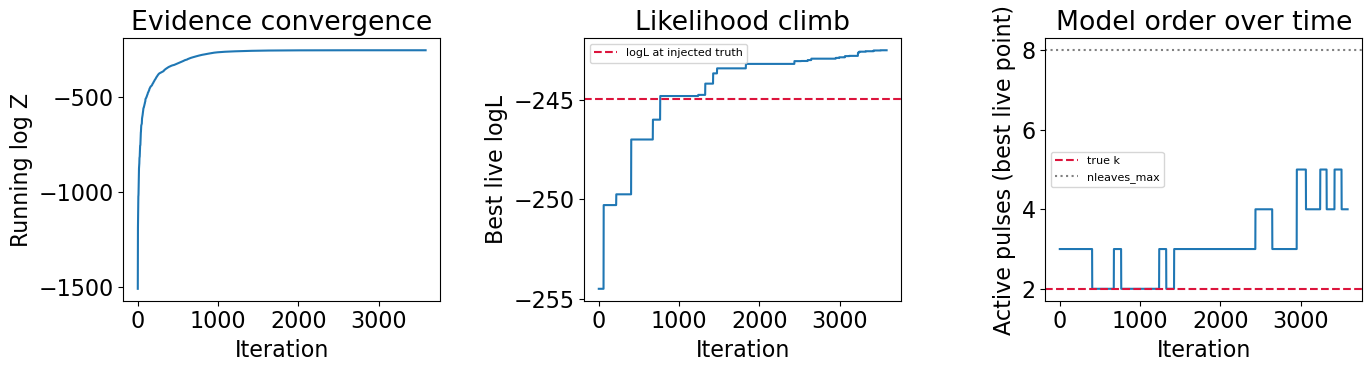

In [9]:
# SECTION 9 - FULL SAMPLER LOOP WITH STOPPING CRITERION


# 9.1 - Loop configuration

# [TUNABLE] Length of the constrained walk performed for each replacement.
#   Too few steps and the walker cannot escape its seed, so the replacement is
#   correlated with a point already in the population and the clone fallback fires
#   more often. More steps cost time linearly and are the first remedy when the
#   fallback fraction reported below is high.
mcmc_steps_per_replacement = 20 * pulse_ndim

# [TUNABLE] Safety ceiling on iterations, not the intended stopping condition.
#   The number of iterations actually required scales as roughly nlive * H, with H
#   the information reported by Section 10, so this ceiling must be revisited
#   whenever number_of_live_points changes. The summary below states which condition
#   ended the loop; reaching this one means the run was truncated, not converged.
maximum_allowed_iterations = 6000

# [TUNABLE] Convergence tolerance: the run stops once the optimistic bound on the
#   remaining evidence contribution falls below this fraction of the evidence
#   accumulated so far. Values between 1e-3 and 1e-2 are conventional. Loosening it
#   ends the run sooner at the cost of truncating the integral slightly earlier.
evidence_convergence_tolerance = 1e-3

log_evidence_convergence_tolerance = np.log(evidence_convergence_tolerance)


# 9.2 - Running evidence bookkeeping

# Monitoring state only. This estimate exists to decide when to stop; the evidence
# reported comes from Section 10.
#
# The guard permits the loop to be re-run to extend a run that hit the ceiling
# without converging: the bookkeeping continues from where it left off, consistent
# with the dead-point archive. Re-running after convergence simply pushes the
# threshold higher into a region contributing nothing, which wastes time without
# improving the answer.

if 'running_log_evidence_estimate' not in locals():

    running_log_evidence_estimate = -np.inf     # log(0): nothing accumulated yet
    running_log_remaining_prior_volume = 0.0    # log(1): the full prior remains
    iteration_count_completed = 0

    log_evidence_history = []
    best_live_logL_history = []
    active_pulse_count_of_best_point_history = []

    print("Initialized running evidence bookkeeping.")

else:
    print(f"Resuming from iteration {iteration_count_completed}, "
          f"running log Z = {running_log_evidence_estimate:.4f}")


# 9.3 - Numerically stable log(exp(a) + exp(b))

def log_add_exp(log_a, log_b):
    """
    Add two numbers represented by their logarithms, without leaving log space.

    The evidence is a sum of many extremely small likelihood-weighted volumes.
    Accumulated in linear space they would underflow to zero almost immediately, so
    the sum is carried in logarithms throughout. Adding logarithms is not the same as
    adding the quantities they represent, hence this helper.

    The largest exponent is factored out before exponentiating, so np.exp never
    receives a large positive argument that would overflow, nor a large negative one
    that would silently round to zero.

    Also used in Section 10 to combine the k = 0 and k >= 1 evidences.
    """
    if log_a == -np.inf:
        return log_b

    if log_b == -np.inf:
        return log_a

    max_val = max(log_a, log_b)

    return max_val + np.log(np.exp(log_a - max_val) + np.exp(log_b - max_val))


# 9.4 - Main loop

loop_terminated_cleanly = False
termination_reason = "reached maximum_allowed_iterations"
log_remaining_contribution_ratio = np.nan

for _ in trange(maximum_allowed_iterations, desc="Nested Sampling"):

    # Step A: discard the worst live point and replace it with one drawn from the
    # constrained prior. All the machinery of Section 8 sits behind this call.
    try:
        discarded_logL, replacement_logL = perform_one_nested_sampling_iteration(
            mcmc_steps_per_replacement=mcmc_steps_per_replacement)

    except RuntimeError as sampling_failure:
        termination_reason = f"live population collapsed: {sampling_failure}"
        print(f"\nSTOPPED EARLY at iteration {iteration_count_completed}: {sampling_failure}")
        break

    iteration_count_completed += 1

    # Step B: shrink the estimated remaining prior volume.
    #
    # Removing the worst of N points leaves, on average, a fraction N/(N+1) of the
    # volume. The shrinkage is multiplicative across iterations, which in log space
    # is a running sum.
    running_log_remaining_prior_volume += np.log(
        number_of_live_points / (number_of_live_points + 1))

    # Step C: accumulate this dead point's contribution, w = L * X / N.
    #
    # X here is the volume AFTER the shrinkage just applied, and X/N is exactly the
    # volume increment this point represents, since X_prev - X = X/N.
    log_weight_this_point = (discarded_logL
                             + running_log_remaining_prior_volume
                             - np.log(number_of_live_points))

    running_log_evidence_estimate = log_add_exp(running_log_evidence_estimate,
                                                log_weight_this_point)

    # Step D: diagnostics.
    best_live_logL = live_point_true_log_likelihood.max()
    best_live_index = int(live_point_true_log_likelihood.argmax())
    active_pulse_count_of_best_point = live_point_active_leaf_mask["gauss"][0, best_live_index].sum()

    # The best live likelihood cannot decrease: the best point is never the worst,
    # so it is never discarded, and every point entering the population exceeds the
    # current threshold. A decrease is therefore proof of a bookkeeping fault rather
    # than ordinary stochastic variation.
    if len(best_live_logL_history) > 0:
        assert best_live_logL >= best_live_logL_history[-1] - 1e-8, (
            f"Best live logL decreased from {best_live_logL_history[-1]:.6f} to "
            f"{best_live_logL:.6f} at iteration {iteration_count_completed}. This is "
            f"impossible under correct bookkeeping.")

    log_evidence_history.append(running_log_evidence_estimate)
    best_live_logL_history.append(best_live_logL)
    active_pulse_count_of_best_point_history.append(active_pulse_count_of_best_point)

    # Step E: stopping criterion, evaluated in log space.
    #
    # The bound is deliberately optimistic: it assumes the whole remaining volume is
    # as likely as the best live point, which it is not. Satisfying it is therefore a
    # real guarantee that continuing would not change the result materially.
    log_max_remaining_contribution = best_live_logL + running_log_remaining_prior_volume

    log_remaining_contribution_ratio = (log_max_remaining_contribution
                                        - running_log_evidence_estimate)

    if log_remaining_contribution_ratio < log_evidence_convergence_tolerance:

        loop_terminated_cleanly = True
        termination_reason = "evidence convergence criterion satisfied"

        print(f"\nConverged at iteration {iteration_count_completed}: "
              f"log(remaining / accumulated) = {log_remaining_contribution_ratio:.3f} "
              f"< log(tol) = {log_evidence_convergence_tolerance:.3f}")
        break


# 9.5 - Post-loop summary

print(f"\nTermination reason    : {termination_reason}")
print(f"Converged cleanly     : {loop_terminated_cleanly}")
print(f"Iterations completed  : {iteration_count_completed}")
print(f"Dead points collected : {dead_point_coordinates.shape[0]}")

if not loop_terminated_cleanly and iteration_count_completed >= maximum_allowed_iterations:
    print("\nWARNING: the run was truncated by the iteration ceiling, not by convergence.")
    print("  logZ is biased low, since the integral was cut short. Raise")
    print("  maximum_allowed_iterations, or re-run this cell to continue from here.")

# Replacement quality. The fallback fraction is computed against the TOTAL, so that
# it is still reported in the worst case, when Eryn produced no valid replacement at
# all and every point was a clone.
total_replacements = replacement_by_eryn_count + replacement_by_clone_fallback_count

print(f"\nReplacements drawn by Eryn RJ-MCMC : {replacement_by_eryn_count}")
print(f"Replacements from clone fallback   : {replacement_by_clone_fallback_count}")
print(f"Survivors rejected as seeds        : {rejected_survivor_count}")
print(f"Walkers stuck at their seed        : {stuck_walker_count}")

if total_replacements > 0:

    fallback_fraction = replacement_by_clone_fallback_count / total_replacements

    if fallback_fraction < 0.02:
        fallback_verdict = "acceptable"
    else:
        fallback_verdict = ("TOO HIGH, logZ is biased. Lengthen "
                            "mcmc_steps_per_replacement or reduce "
                            "gaussian_move_step_size_scale.")

    print(f"Fallback fraction                  : {fallback_fraction:.1%}  ({fallback_verdict})")

print(f"\nlog Z (k >= 1, running estimate)   : {running_log_evidence_estimate:.4f}")
print(f"log Z (k = 0, analytic)            : {log_evidence_no_signal_model:.4f}")
print(f"log Bayes factor, signal vs noise  : "
      f"{running_log_evidence_estimate - log_evidence_no_signal_model:.4f}")
print("  (running estimate only; Section 10 reports the value with its uncertainty)")


# 9.6 - [OPTIONAL] Raw model-order tally across the dead points

# How many active pulses did each discarded point hold? This shows where the sampler
# spent its exploration, which is useful for orientation, but it is emphatically NOT
# the posterior over k: every point is counted once here, whereas the posterior
# weights each point by its evidence contribution. Section 10 does that properly.

dead_point_model_order = dead_point_active_leaf_mask.sum(axis=-1).astype(int)

model_order_counts = np.bincount(dead_point_model_order,
                                 minlength=nleaves_max["gauss"] + 1)

print("\nModel-order counts among all dead points (raw, unweighted):")

for k_value, count in enumerate(model_order_counts):

    marker = "   <-- TRUE" if k_value == true_number_of_pulses else ""

    if k_value == nleaves_max["gauss"] and count > 0.1 * model_order_counts.sum():
        marker += "   [CEILING SATURATED - raise nleaves_max]"

    print(f"  k = {k_value:2d} : {count}{marker}")

print("\nThese are raw counts. The posterior over k requires the Nested Sampling")
print("weights and is computed in Section 10.")


# 9.7 - [OPTIONAL] Diagnostic plots

# Three views of the run:
#   left   - has the evidence estimate flattened?
#   middle - has the best live likelihood climbed to the injected value and levelled?
#   right  - has the model order settled near the truth?

# Recomputed here under the name Section 10 expects. Numerically identical to
# true_log_likelihood_at_injected_truth from Section 4.4.
log_likelihood_at_injected_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis,
    observed_data, noise_standard_deviation)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(log_evidence_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Running log Z")
axes[0].set_title("Evidence convergence")

axes[1].plot(best_live_logL_history)
axes[1].axhline(log_likelihood_at_injected_truth, color="crimson", linestyle="--",
                label="logL at injected truth")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Best live logL")
axes[1].set_title("Likelihood climb")
axes[1].legend(fontsize=8)

axes[2].plot(active_pulse_count_of_best_point_history)
axes[2].axhline(true_number_of_pulses, color="crimson", linestyle="--", label="true k")
axes[2].axhline(nleaves_max["gauss"], color="grey", linestyle=":", label="nleaves_max")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Active pulses (best live point)")
axes[2].set_title("Model order over time")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

if true_number_of_pulses == 0:
    print("\nNOTE: this run injected NO signal (k=0). The right panel cannot show k")
    print("converging to 0, since Eryn's RJ-MCMC only ever explores k >= 1 by")
    print("construction (Section 5). The correct verdict for this run comes from")
    print("the Bayes factor and P(k=0) in Section 10, not from this panel.")

## Section 10 — Evidence, Trace Plots, and the Posterior on the Number of Pulses

This section converts the archive built by the preceding sections into the three
results a model-selection analysis is expected to report: the evidence with its
uncertainty, the posterior over model order $k$, and the posterior over the
continuous pulse parameters.

### Folding the live points into the archive

When the Section 9 loop stops, the surviving live points still hold a real share of
the remaining prior mass. That is precisely what the stopping criterion asserts: the
remaining contribution is small, not zero. Discarding them would throw away genuine
evidence weight and bias $\log\mathcal{Z}$ low.

They are therefore appended to the dead-point archive as a final batch, each carrying
the true log-likelihood and birth threshold already recorded for it. This is
Skilling's final correction, and it requires no new bookkeeping because the necessary
quantities have been maintained since Section 8.

### Why the weights need not be computed by hand

Every point in the archive carries the constraint threshold active when it was born.
From the sequence of $(\log\mathcal{L}, \log\mathcal{L}_{\text{birth}})$ pairs alone,
`anesthetic` reconstructs the entire live-point count history, and from that the
correct Nested Sampling weights. It is never told $N_{\text{live}}$.

That independence matters here rather than being a convenience. The running estimator
of Section 9 assumes a perfectly constant population, which the clone fallback
violates: a cloned point occupies a slot without contributing new information, so the
effective population is smaller than the nominal count. Reconstructing the weights
from recorded birth contours reflects what the run actually did.

The two evidence figures will therefore differ. The Section 9 value is a monitoring
estimate under an assumption known to be imperfect; the value reported here is the
result, and it carries an uncertainty.

### Why the parameter column handed to `anesthetic` is $k$

`NestedSamples` expects a parameter table of fixed dimensionality, whereas this
problem is trans-dimensional by construction. Rather than impose an artificial
fixed-length encoding on a variable-length parameter vector, the table is given the
one scalar that is well defined at every point regardless of $k$: the number of
active pulses. This is not a compromise, since it is the quantity the analysis exists
to infer.

The continuous parameters are handled separately below, by flattening every active
leaf across every archived point into a single table, each row inheriting its parent
point's weight. The resulting distribution is a posterior over **detected pulses**
rather than over sampled points: a point holding five pulses contributes five rows,
so higher-$k$ configurations occupy proportionally more of the table. That is the
intended reading, since each active leaf represents one inferred pulse.

### Combining with the analytic $k=0$ evidence

The Nested Sampling run produced $\mathcal{Z}_{k\geq1}$, the evidence conditional on
at least one pulse being present, since `nleaves_min` is 1. The total evidence
requires the analytic $k=0$ term from Section 5:

$$
\mathcal{Z}_{\text{total}} = \mathcal{Z}_{k=0} + \mathcal{Z}_{k\geq1}
$$

Recovering the full posterior over $k$ then requires rescaling. The weights returned
by `anesthetic` are normalised within the $k \geq 1$ model, so each is multiplied by
$\mathcal{Z}_{k\geq1}/\mathcal{Z}_{\text{total}}$, while $P(k=0)$ is
$\mathcal{Z}_{k=0}/\mathcal{Z}_{\text{total}}$ directly. Omitting this rescaling
would place the two hypotheses on incomparable scales, one a single point evidence
and the other an integral over a population.

The combination also encodes a prior. Weighting the two evidences equally assigns
equal prior probability to the presence and absence of signal, which is the
conventional detection prior and the default used here. It is nonetheless a choice
rather than a neutral position, and it is exposed explicitly below so that it can be
stated when the result is reported, or altered if a different prior is warranted.

### Reading the diagnostics

Nested Sampling weights are extremely uneven: the overwhelming majority of archived
points carry negligible weight, and the posterior is supported by a small fraction of
them. The effective sample size reported below measures how many points are doing the
work. A corner plot built from a small effective sample is noise regardless of how
many rows the underlying table contains, and the remedy is more live points rather
than more iterations.

The likelihood trace should rise and then flatten. A plateau materially above the
likelihood of the injected truth is expected rather than alarming: configurations
with more pulses than were injected can fit this particular noise realisation more
closely. Penalising exactly that behaviour is what the evidence does, which is why
the posterior over $k$ does not simply select whichever $k$ attains the highest
likelihood.

Finalized archive: 3585 dead points + 200 live points = 3785 total.

log Z (k >= 1, signal present) : -253.495 +/- 0.194
log Z (k = 0, analytic)        : -328.178
Information H                  : 7.613 nats
  Expected run length ~ nlive * H = 1523 iterations (actual: 3584)

log Bayes factor, log(Z_signal / Z_noise) : 74.684
  Positive favours signal present. On the conventional scale, above 5 is
  strong evidence and above 10 is decisive.

Posterior P(k | data), with prior odds 1:1 for signal against no signal:
  P(k =  0) = 0.0000
  P(k =  1) = 0.1049
  P(k =  2) = 0.5036   <-- TRUE
  P(k =  3) = 0.2851
  P(k =  4) = 0.0849
  P(k =  5) = 0.0172
  P(k =  6) = 0.0043
  P(k =  7) = 0.0000
  P(k =  8) = 0.0000

MAP estimate : k = 2   (true value: 2)


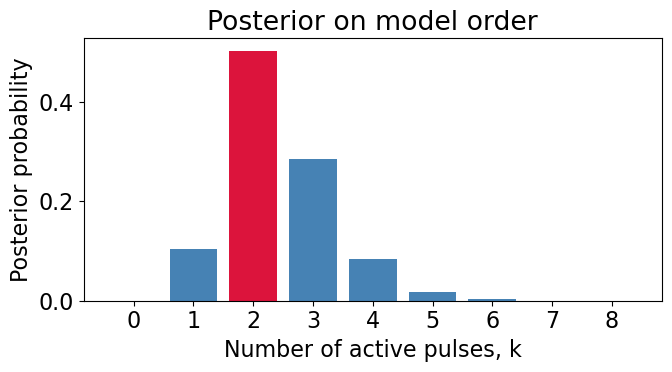


Effective sample size : 1218 out of 3785 archived points
Flattened 10889 individual pulse samples for the parameter posterior.


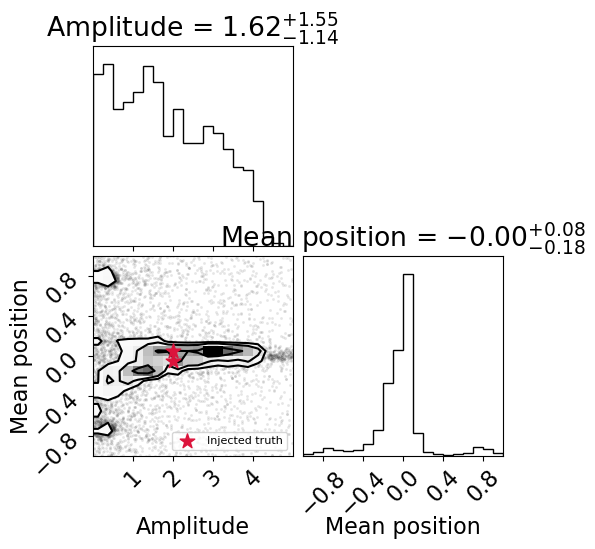

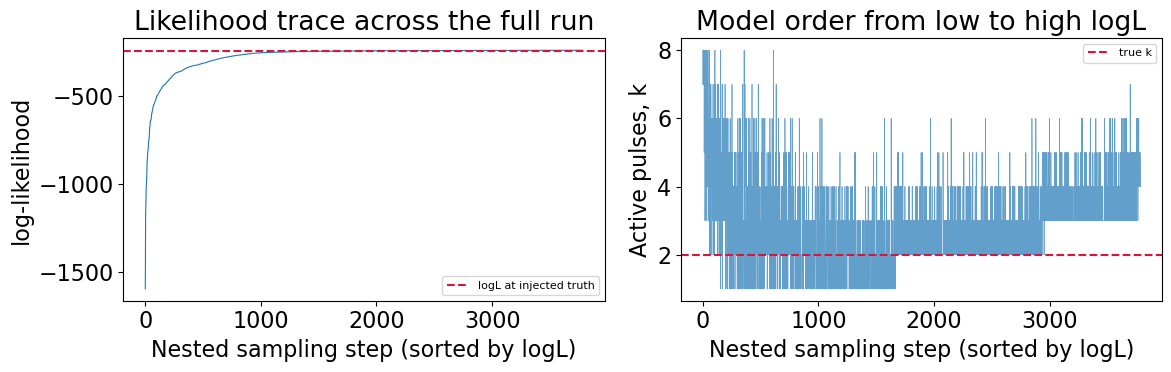


How to read these panels:
  Left  : should rise and then flatten. A plateau above the injected logL is
          expected, since extra pulses can fit this noise realisation more
          closely; the evidence is what penalises that.
  Right : k should wander broadly at low logL, where the constraint is loose,
          and concentrate near the true value at high logL. That progression
          is the signature of model order being inferred rather than assumed.


In [10]:
# SECTION 10 - POST-PROCESSING: EVIDENCE, POSTERIOR ON k, PARAMETER POSTERIORS

try:
    from anesthetic import NestedSamples
except ImportError:
    raise ImportError(
        "anesthetic is not installed in this environment. Run:\n"
        "    pip install anesthetic\n"
        "then restart the kernel and re-run from Section 1."
    )


# 10.1 - Fold the surviving live points into the archive

# The live points still hold a real share of the remaining prior mass, which is what
# the stopping criterion asserts to be small rather than zero. They are appended as a
# final batch, using the true log-likelihood and birth threshold already recorded for
# each. This is Skilling's final correction.

final_all_coordinates = np.concatenate(
    [dead_point_coordinates, live_point_coordinates["gauss"][0]], axis=0
)

final_all_active_leaf_mask = np.concatenate(
    [dead_point_active_leaf_mask, live_point_active_leaf_mask["gauss"][0]], axis=0
)

final_all_log_likelihood = np.concatenate(
    [dead_point_log_likelihood, live_point_true_log_likelihood], axis=0
)

final_all_birth_log_likelihood = np.concatenate(
    [dead_point_birth_log_likelihood, live_point_birth_log_likelihood], axis=0
)

number_of_points_total = final_all_log_likelihood.shape[0]

print(f"Finalized archive: {dead_point_coordinates.shape[0]} dead points + "
      f"{number_of_live_points} live points = {number_of_points_total} total.")

# A point cannot be born above its own likelihood, since it had to exceed the
# threshold in force at its birth. Violation indicates a bookkeeping fault. The
# tolerance absorbs floating-point equality.
assert np.all(final_all_birth_log_likelihood <= final_all_log_likelihood + 1e-8), \
    "Found a point whose birth threshold exceeds its own logL. Bookkeeping bug."


# 10.2 - Build the anesthetic table

# The parameter column is the model order k, the one quantity well defined at every
# point in a trans-dimensional space. anesthetic infers the entire live-point history
# from the (logL, logL_birth) pairs and is never told nlive.

# A second column carries the original row index. anesthetic SORTS its rows by logL
# internally, so the weights it returns are not in the order of our arrays. Recording
# the original position lets that permutation be undone exactly, rather than assumed
# away.

model_order_per_point = final_all_active_leaf_mask.sum(axis=-1).astype(float)
original_row_index_per_point = np.arange(number_of_points_total, dtype=float)

nested_samples = NestedSamples(
    data=np.column_stack([model_order_per_point, original_row_index_per_point]),
    logL=final_all_log_likelihood,
    logL_birth=final_all_birth_log_likelihood,
    columns=["k", "row_id"],
)


# 10.3 - Evidence, uncertainty, and information

log_evidence_signal_model = float(nested_samples.logZ())

# The Kullback-Leibler divergence from prior to posterior, in nats. This is the H
# appearing in the standard error estimate sigma_logZ ~ sqrt(H / nlive), and it also
# sets the expected run length, roughly nlive * H iterations.
information_nats = float(nested_samples.D_KL())

# The uncertainty is obtained by resampling the volume history: anesthetic returns
# many statistically valid alternative realisations of the same run, and their spread
# is the error on logZ.

# The returned object is an anesthetic WeightedSeries rather than an ndarray, and
# np.std would dispatch to its own weighted implementation, which in some versions
# rejects the keyword arguments NumPy passes through. Converting first avoids that.
log_evidence_bootstrap_draws = nested_samples.logZ(nsamples=1000)
log_evidence_bootstrap_draws_array = np.asarray(log_evidence_bootstrap_draws)
log_evidence_signal_std = float(np.std(log_evidence_bootstrap_draws_array))

print(f"\nlog Z (k >= 1, signal present) : {log_evidence_signal_model:.3f} "
      f"+/- {log_evidence_signal_std:.3f}")
print(f"log Z (k = 0, analytic)        : {log_evidence_no_signal_model:.3f}")
print(f"Information H                  : {information_nats:.3f} nats")
print(f"  Expected run length ~ nlive * H = "
      f"{number_of_live_points * information_nats:.0f} iterations "
      f"(actual: {iteration_count_completed})")

# The Bayes factor is a ratio of evidences and is therefore independent of any prior
# on the hypotheses. It is the model-comparison result proper.
log_bayes_factor_signal_vs_noise = log_evidence_signal_model - log_evidence_no_signal_model

print(f"\nlog Bayes factor, log(Z_signal / Z_noise) : "
      f"{log_bayes_factor_signal_vs_noise:.3f}")
print("  Positive favours signal present. On the conventional scale, above 5 is")
print("  strong evidence and above 10 is decisive.")


# 10.4 - Full posterior over k, including k = 0

# [TUNABLE] Prior odds of "signal present" against "no signal".
#   1.0 assigns equal prior probability to the two hypotheses, which is the
#   conventional detection prior and the default. Lowering it encodes scepticism that
#   any signal is present, which is appropriate when searching many independent data
#   segments where detections are rare.
#   This affects the posterior over k reported below. It does NOT affect the Bayes
#   factor above, which is a ratio of evidences alone.
prior_odds_signal_vs_no_signal = 1.0

log_prior_odds_signal_vs_no_signal = np.log(prior_odds_signal_vs_no_signal)

# Weights of every archived point, normalised within the k >= 1 model. These come
# back in anesthetic's own row order, which is sorted by logL and therefore differs
# from the order of our arrays.
posterior_weights_anesthetic_order = np.asarray(nested_samples.get_weights())

# The row_id column travelled through the sort alongside the weights, so it states
# exactly where each returned weight belongs in our original arrays.
row_id_anesthetic_order = np.asarray(nested_samples["row_id"]).astype(int)

# anesthetic may discard rows it considers invalid, for instance a point whose birth
# threshold is not strictly below its own likelihood. Such points exist here only as
# a consequence of the clone fallback, so a mismatch is worth surfacing rather than
# silently absorbing.
if len(posterior_weights_anesthetic_order) != number_of_points_total:
    print(f"\nNOTE: anesthetic retained "
          f"{len(posterior_weights_anesthetic_order)} of {number_of_points_total} points. "
          f"Points dropped by anesthetic receive zero weight below.")

# Undo the permutation: place each weight at the position its point occupies in
# final_all_coordinates and model_order_per_point.
posterior_weights = np.zeros(number_of_points_total)
posterior_weights[row_id_anesthetic_order] = posterior_weights_anesthetic_order

assert np.all(np.isfinite(posterior_weights)), \
    "Non-finite posterior weight after reordering."

assert posterior_weights.sum() > 0, \
    "All posterior weights are zero. The archive carries no evidence weight."

posterior_weights = posterior_weights / posterior_weights.sum()

posterior_weights = posterior_weights / posterior_weights.sum()

# Split the total posterior mass between the two hypotheses, including the prior odds.
log_signal_mass_unnormalised = log_evidence_signal_model + log_prior_odds_signal_vs_no_signal
log_evidence_total = log_add_exp(log_signal_mass_unnormalised, log_evidence_no_signal_model)

signal_model_posterior_mass = np.exp(log_signal_mass_unnormalised - log_evidence_total)
no_signal_posterior_mass = np.exp(log_evidence_no_signal_model - log_evidence_total)

# k = 0 takes its share directly. Every k >= 1 takes its conditional weight within the
# signal model, rescaled onto the absolute scale shared with k = 0.
k_values_full_range = np.arange(0, nleaves_max["gauss"] + 1)
posterior_probability_per_k = np.zeros_like(k_values_full_range, dtype=float)

posterior_probability_per_k[0] = no_signal_posterior_mass

for k_value in range(1, nleaves_max["gauss"] + 1):

    conditional_mass_this_k = posterior_weights[model_order_per_point == k_value].sum()
    posterior_probability_per_k[k_value] = conditional_mass_this_k * signal_model_posterior_mass

assert np.isclose(posterior_probability_per_k.sum(), 1.0, atol=1e-6), \
    f"Posterior over k does not sum to 1 (got {posterior_probability_per_k.sum():.6f})."

print(f"\nPosterior P(k | data), with prior odds "
      f"{prior_odds_signal_vs_no_signal:g}:1 for signal against no signal:")

for k_value, probability in zip(k_values_full_range, posterior_probability_per_k):
    marker = "   <-- TRUE" if k_value == true_number_of_pulses else ""
    print(f"  P(k = {k_value:2d}) = {probability:.4f}{marker}")

map_k_estimate = int(k_values_full_range[np.argmax(posterior_probability_per_k)])

print(f"\nMAP estimate : k = {map_k_estimate}   (true value: {true_number_of_pulses})")

plt.figure(figsize=(7, 4))
bar_colors = ["crimson" if k == true_number_of_pulses else "steelblue"
              for k in k_values_full_range]
plt.bar(k_values_full_range, posterior_probability_per_k, color=bar_colors)
plt.xlabel("Number of active pulses, k")
plt.ylabel("Posterior probability")
plt.title("Posterior on model order")
plt.xticks(k_values_full_range)
plt.tight_layout()
plt.show()


# 10.5 - Posterior on the continuous pulse parameters

# Effective sample size, 1 / sum(w^2). Nested Sampling weights are extremely uneven,
# so the archive is far larger than the number of points actually supporting the
# posterior. A small effective sample makes the corner plot below unreliable however
# many rows it was built from, and the remedy is more live points, not more
# iterations.
effective_sample_size = 1.0 / np.sum(posterior_weights ** 2)

print(f"\nEffective sample size : {effective_sample_size:.0f} "
      f"out of {number_of_points_total} archived points")

if effective_sample_size < 100:
    print("  WARNING: too few effective samples for reliable parameter posteriors.")
    print("  Increase number_of_live_points and re-run from Section 6.")

# Flatten every active leaf across every point into one table. Each leaf inherits its
# parent point's full weight rather than a share of it, because each leaf represents
# one inferred pulse in its own right. The resulting distribution is therefore a
# posterior over detected pulses: a point holding five pulses contributes five rows.

flattened_active_parameters = []
flattened_parameter_weights = []

for point_index in range(number_of_points_total):

    active_mask_this_point = final_all_active_leaf_mask[point_index]
    active_params_this_point = final_all_coordinates[point_index][active_mask_this_point]
    n_active_this_point = active_params_this_point.shape[0]

    if n_active_this_point == 0:
        continue

    flattened_active_parameters.append(active_params_this_point)
    flattened_parameter_weights.append(
        np.full(n_active_this_point, posterior_weights[point_index])
    )

flattened_active_parameters = np.concatenate(flattened_active_parameters, axis=0)
flattened_parameter_weights = np.concatenate(flattened_parameter_weights, axis=0)
flattened_parameter_weights = flattened_parameter_weights / flattened_parameter_weights.sum()

print(f"Flattened {flattened_active_parameters.shape[0]} individual pulse samples "
      f"for the parameter posterior.")

corner_figure = corner.corner(
    flattened_active_parameters,
    weights=flattened_parameter_weights,
    labels=["Amplitude", "Mean position"],
    truths=None,   # a single truth is undefined here; the injected pulses are overlaid below
    show_titles=True,
)

# Overlay the injected pulses on the joint panel. In a corner plot the lower-left
# panel carries column 0 on the horizontal axis and column 1 on the vertical,
# matching the (amplitude, mean position) convention used throughout.
corner_axes = np.array(corner_figure.axes).reshape((2, 2))
scatter_ax = corner_axes[1, 0]

# Skipped entirely in the null test, where nothing was injected and there is no
# truth to mark.
if true_number_of_pulses > 0:

    true_params_array = np.asarray(true_injected_pulse_parameters)

    scatter_ax.scatter(true_params_array[:, 0], true_params_array[:, 1],
                       color="crimson", marker="*", s=120, zorder=10,
                       label="Injected truth")
    scatter_ax.legend(fontsize=8)

plt.show()


# 10.6 - [OPTIONAL] Trace plots across the full sequence

# Dead points were archived in increasing order of logL, but the live points appended
# in 10.1 were not sorted, so the combined table is sorted here to recover the true
# Nested Sampling sequence from the base of the likelihood surface to its peak.

# Recomputed rather than reused from Section 9.7, so that this cell does not depend
# on the optional diagnostics there having been run.
log_likelihood_at_injected_truth = true_gaussian_log_likelihood(
    np.asarray(true_injected_pulse_parameters), time_axis,
    observed_data, noise_standard_deviation)

sort_order_by_logL = np.argsort(final_all_log_likelihood)
sorted_logL = final_all_log_likelihood[sort_order_by_logL]
sorted_model_order = model_order_per_point[sort_order_by_logL]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sorted_logL, lw=0.8)
axes[0].axhline(log_likelihood_at_injected_truth, color="crimson", linestyle="--",
                label="logL at injected truth")
axes[0].set_xlabel("Nested sampling step (sorted by logL)")
axes[0].set_ylabel("log-likelihood")
axes[0].set_title("Likelihood trace across the full run")
axes[0].legend(fontsize=8)

axes[1].plot(sorted_model_order, lw=0.5, alpha=0.7)
axes[1].axhline(true_number_of_pulses, color="crimson", linestyle="--", label="true k")
axes[1].set_xlabel("Nested sampling step (sorted by logL)")
axes[1].set_ylabel("Active pulses, k")
axes[1].set_title("Model order from low to high logL")
axes[1].legend(fontsize=8)

plt.tight_layout()

corner_figure.suptitle(
    f"Conditional on signal present (P(k>=1) = {signal_model_posterior_mass:.1%} "
    f"of total posterior mass)",
    fontsize=10, y=1.02
)

plt.show()

print("\nHow to read these panels:")
print("  Left  : should rise and then flatten. A plateau above the injected logL is")
print("          expected, since extra pulses can fit this noise realisation more")
print("          closely; the evidence is what penalises that.")
print("  Right : k should wander broadly at low logL, where the constraint is loose,")
print("          and concentrate near the true value at high logL. That progression")
print("          is the signature of model order being inferred rather than assumed.")